# Ratings Analysis: LLM vs. Expert UI Ratings

Compares the 1–10 / 1–5 ratings of each LLM (zero-shot and few-shot) against the UICrit expert ratings:
descriptive statistics, systematic bias (Wilcoxon), overall agreement (Brennan–Prediger κ),
where the models fail, and supplementary analyses.

# 1. Setup

In [1]:
import base64
import string
import sys
from io import BytesIO
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from irrCAC.raw import CAC
from matplotlib.patches import Patch
from PIL import Image
from scipy.stats import shapiro, wilcoxon

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'utils' / 'paths.py').exists())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
from utils.paths import PARSED_DIR, PREPROCESSED_DIR, RESULTS_DIR as ALL_RESULTS_DIR
from utils.data_setup import load_existing_responses
from utils.inference_utils import EVALUATION_FIVE_ASPECTS as ASPECTS
from utils.statistical_analysis_utils import bp_kappa, compute_manova

In [2]:
TASK_SUBSET = "1000_tasks"   # "all_tasks" | "1000_tasks"
STAGE = "ratings"
NUM_TRIALS = 1
PROMPTINGS = ["zero_shot", "few_shot"]
PROMPT_LABELS = {"zero_shot": "Zero-shot", "few_shot": "Few-shot"}
PROMPT_ALPHA = {"zero_shot": 0.45, "few_shot": 0.9}   # light = zero-shot, dark = few-shot in all plots

# display name -> short name used in result files (dict order = display order)
MODELS = {"GPT-5": "gpt5", "Gemini-2.5": "gemini2_5pro", "Claude-4": "claude4", "Qwen-3": "qwen3_vl"}
MODEL_COLORS = {"Expert": "#9E9E9E", "GPT-5": "#5288C1", "Gemini-2.5": "#73C068", "Claude-4": "#F89838", "Qwen-3": "#AF4EC5"}

SCALES = {"aesthetics_rating": 10, "learnability": 5, "efficiency": 5, "usability_rating": 10, "design_quality_rating": 10}
CATEGORIES = {a: list(range(1, n + 1)) for a, n in SCALES.items()}
ASPECTS_10 = [a for a in ASPECTS if SCALES[a] == 10]
ASPECTS_5 = [a for a in ASPECTS if SCALES[a] == 5]
GRID_ASPECTS = ASPECTS_10 + ASPECTS_5          # panel order in 2×3 aspect grids
ASPECT_LABELS = {a: a.replace("_rating", "").replace("_", " ").title() for a in ASPECTS}
SCORE_BINS = {10: ([0, 3, 7, 10], ["Low (1–3)", "Mid (4–7)", "High (8–10)"]),
              5: ([0, 2, 4, 5], ["Low (1–2)", "Mid (3–4)", "High (5)"])}
SHIFT_COLORS = {"below": "#4C72B0", "same": "#DDDDDD", "above": "#C44E52"}
DELTA_YLIM = {10: (-7.5, 6.5), 5: (-3.5, 3.5)}
MIN_PAIRS = 10
MIN_CATEGORY_SCREENS = 30   # smaller app categories are pooled into "Other"
ALPHA = 0.05

UICRIT_FILE = PREPROCESSED_DIR / "uicrit_notna.parquet"
SCREENS_FILE = UICRIT_FILE.with_name("screenshots.parquet")
RESULTS_DIR = ALL_RESULTS_DIR / STAGE
TABLES_DIR = RESULTS_DIR / "analysis" / "tables"

In [3]:
def p_stars(p):
    return "" if pd.isna(p) else "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

def fmt_p(p):
    return "p<0.001" if p < 0.001 else f"p={p:.3f}"

def legend_handles(with_expert=False, with_prompting=True):
    """Model colours (plus zero-/few-shot shading), shared by all grouped plots."""
    handles = [Patch(color=MODEL_COLORS["Expert"], label="Expert")] if with_expert else []
    handles += [Patch(color=MODEL_COLORS[m], label=m) for m in MODELS]
    if with_prompting:
        handles += [Patch(facecolor="dimgrey", alpha=PROMPT_ALPHA[p], label=PROMPT_LABELS[p]) for p in PROMPTINGS]
    return handles

def aspect_grid(title, legend=None, figsize=(16, 9)):
    """2×3 grid: 10-point aspects on top, 5-point below, legend in the spare panel. Returns fig, {aspect: ax}."""
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes.flat[-1].axis("off")
    if legend:
        axes.flat[-1].legend(handles=legend, loc="center", frameon=False, fontsize=11)
    fig.suptitle(title, fontsize=15, weight="bold")
    return fig, dict(zip(GRID_ASPECTS, axes.flat))

def panel_title(aspect):
    return f"({string.ascii_lowercase[GRID_ASPECTS.index(aspect)]}) {ASPECT_LABELS[aspect]}"

# 2. Load Data

In [4]:
experts_df = pd.read_parquet(UICRIT_FILE, columns=["screen_task_id", "screen_id", *ASPECTS])

def load_model_responses(prompting):
    """Load every model's responses for one prompting type, merged with the expert ratings."""
    dfs = {}
    for model, short in MODELS.items():
        path = RESULTS_DIR / "responses" / f"{STAGE}-{prompting}-{TASK_SUBSET}-{short}-responses.parquet"
        df = (load_existing_responses(path, UICRIT_FILE, NUM_TRIALS, STAGE)
              .rename(columns={a: f"{a}_llm" for a in ASPECTS})
              .merge(experts_df, on=["screen_task_id", "screen_id"]))
        print(f"{prompting} | {model} shape: {df.shape} | N/A count:", df.isna().sum().sum())
        dfs[model] = df
    return dfs

model_dfs = {p: load_model_responses(p) for p in PROMPTINGS}

# Expert ratings of the screens the models rated
rated_ids = pd.concat([df["screen_task_id"] for df in model_dfs["zero_shot"].values()]).unique()
experts_rated = experts_df[experts_df["screen_task_id"].isin(rated_ids)]
print("experts_rated shape:", experts_rated.shape)

zero_shot | GPT-5 shape: (1000, 13) | N/A count: 0
zero_shot | Gemini-2.5 shape: (1000, 13) | N/A count: 0
zero_shot | Claude-4 shape: (1000, 13) | N/A count: 0
zero_shot | Qwen-3 shape: (1000, 13) | N/A count: 5
few_shot | GPT-5 shape: (997, 13) | N/A count: 0
few_shot | Gemini-2.5 shape: (997, 13) | N/A count: 0
few_shot | Claude-4 shape: (997, 13) | N/A count: 0
few_shot | Qwen-3 shape: (997, 13) | N/A count: 5
experts_rated shape: (1000, 7)


**Long format**: one row per screen × model × prompting × aspect, with `delta = llm_score − expert_score`.
`screen_meta` adds the app category and the number of issues the experts flagged (human comments) per screen.

In [5]:
ratings_long = pd.concat([
    df.assign(model=model, prompting=prompting, aspect=aspect,
              expert_score=df[aspect], llm_score=df[f"{aspect}_llm"])
      [["screen_task_id", "screen_id", "model", "prompting", "aspect", "expert_score", "llm_score"]]
    for prompting, dfs in model_dfs.items() for model, df in dfs.items() for aspect in ASPECTS
], ignore_index=True)
ratings_long["delta"] = ratings_long["llm_score"] - ratings_long["expert_score"]

# Experts + LLMs in one frame for descriptive plots
scores_long = pd.concat([
    experts_rated.melt(id_vars="screen_task_id", value_vars=ASPECTS, var_name="aspect", value_name="score")
                 .assign(source="Expert", prompting="expert"),
    ratings_long.rename(columns={"model": "source", "llm_score": "score"})
                [["screen_task_id", "aspect", "score", "source", "prompting"]],
], ignore_index=True).dropna(subset=["score"])

# Expert issues = human-written comments, identified by their "Comment N" / "LLM Comment N" label
screen_meta = pd.read_parquet(PARSED_DIR / "uicrit_notna_parsed.parquet",
                              columns=["screen_task_id", "app_category", "parsed_comments"])
screen_meta = screen_meta[screen_meta["screen_task_id"].isin(rated_ids)].assign(
    n_issues=lambda d: d.pop("parsed_comments").apply(lambda cs: sum(c["comment_source"] == "Human" for c in cs)))

In [6]:
def paired_scores(min_pairs=MIN_PAIRS):
    """Yield (prompting, aspect, model, pairs): NaN-free expert/LLM score pairs per comparison."""
    for (prompting, aspect), df in ratings_long.groupby(["prompting", "aspect"]):
        for model in df["model"].unique():
            pairs = df.loc[df["model"] == model, ["screen_task_id", "expert_score", "llm_score"]].dropna()
            if len(pairs) >= min_pairs:
                yield prompting, aspect, model, pairs.astype({"expert_score": int, "llm_score": int})

def per_comparison_table(stat_fn):
    """One row per prompting × aspect × model with the stats returned by stat_fn(pairs, aspect)."""
    return pd.DataFrame([
        {"prompting": p, "aspect": a, "model": m, "n_pairs": len(pairs), **stat_fn(pairs, a)}
        for p, a, m, pairs in paired_scores()
    ])

def by_model_prompting(df, value, fmt="{:.2f}"):
    """Compact view: rows = model × prompting, columns = aspects."""
    out = df.pivot_table(index=["model", "prompting"], columns="aspect", values=value)[ASPECTS]
    out = out.reindex(pd.MultiIndex.from_product([MODELS, PROMPTINGS]))
    return out.rename(columns=ASPECT_LABELS, index=PROMPT_LABELS).map(fmt.format)

# 3. Descriptive Statistics

## 3.1 Rating Summary
Mean ± SD (median) per source. The full table (quartiles, range) is saved in Section 9.

In [7]:
rating_summary = (
    scores_long.groupby(["aspect", "source", "prompting"], sort=False)["score"]
    .agg(n="count", mean="mean", sd="std", median="median",
         q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), min="min", max="max")
    .reset_index()
)
(rating_summary
 .assign(cell=lambda d: d["mean"].map("{:.2f}".format) + " ± " + d["sd"].map("{:.2f}".format)
                       + " (" + d["median"].map("{:g}".format) + ")",
         aspect=lambda d: d["aspect"].map(ASPECT_LABELS),
         prompting=lambda d: d["prompting"].replace({"expert": "", **PROMPT_LABELS}))
 .pivot(index=["source", "prompting"], columns="aspect", values="cell")
 .reindex(columns=[ASPECT_LABELS[a] for a in ASPECTS])
 .reindex([("Expert", ""), *((m, PROMPT_LABELS[p]) for m in MODELS for p in PROMPTINGS)]))

aspect                     Aesthetics     Learnability       Efficiency  \
source     prompting                                                      
Expert                5.80 ± 1.07 (6)  2.98 ± 0.62 (3)  3.01 ± 0.66 (3)   
GPT-5      Zero-shot  5.88 ± 1.47 (6)  4.00 ± 0.81 (4)  3.69 ± 0.87 (4)   
           Few-shot   5.81 ± 1.82 (6)  4.18 ± 0.90 (4)  3.88 ± 0.88 (4)   
Gemini-2.5 Zero-shot  4.34 ± 1.90 (4)  4.39 ± 1.05 (5)  4.12 ± 1.26 (5)   
           Few-shot   5.31 ± 2.41 (4)  4.53 ± 1.02 (5)  4.30 ± 1.12 (5)   
Claude-4   Zero-shot  6.29 ± 0.91 (6)  4.22 ± 0.79 (4)  4.06 ± 0.98 (4)   
           Few-shot   6.53 ± 1.24 (7)  4.24 ± 0.63 (4)  4.17 ± 0.67 (4)   
Qwen-3     Zero-shot  6.12 ± 0.95 (6)  4.33 ± 0.68 (4)  4.08 ± 0.84 (4)   
           Few-shot   6.48 ± 1.33 (7)  4.57 ± 0.73 (5)  4.18 ± 0.80 (4)   

aspect                      Usability   Design Quality  
source     prompting                                    
Expert                5.84 ± 1.07 (6)  5.88 ± 1.01 (6)  
GPT-5      Zero-shot  6.96 ± 1.70 (7)  5.80 ± 1.43 (6)  
           Few-shot   7.71 ± 1.71 (8)  6.18 ± 1.71 (7)  
Gemini-2.5 Zero-shot  7.49 ± 2.48 (9)  4.69 ± 2.06 (4)  
           Few-shot   8.48 ± 2.25 (9)  5.43 ± 2.51 (4)  
Claude-4   Zero-shot  7.87 ± 1.76 (8)  6.32 ± 1.01 (7)  
           Few-shot   8.32 ± 1.21 (8)  6.82 ± 1.14 (7)  
Qwen-3     Zero-shot  7.65 ± 1.68 (7)  5.98 ± 1.06 (6)  
           Few-shot   8.75 ± 1.45 (9)  6.59 ± 1.37 (7)

In [8]:
normality_p = [shapiro(experts_rated[a])[1] for a in ASPECTS] + [
    shapiro(df["llm_score"].dropna())[1] for _, df in ratings_long.groupby(["model", "prompting", "aspect"])]
print(f"Shapiro–Wilk: largest p = {max(normality_p):.1e} over {len(normality_p)} distributions "
      f"-> {'none' if max(normality_p) < ALPHA else 'not all'} normal, so the tests below are non-parametric.")
print(f"Δ range: {ratings_long['delta'].min():g} to {ratings_long['delta'].max():g}")

Shapiro–Wilk: largest p = 1.2e-21 over 45 distributions -> none normal, so the tests below are non-parametric.
Δ range: -7 to 6


## 3.2 Expert Rating Distributions

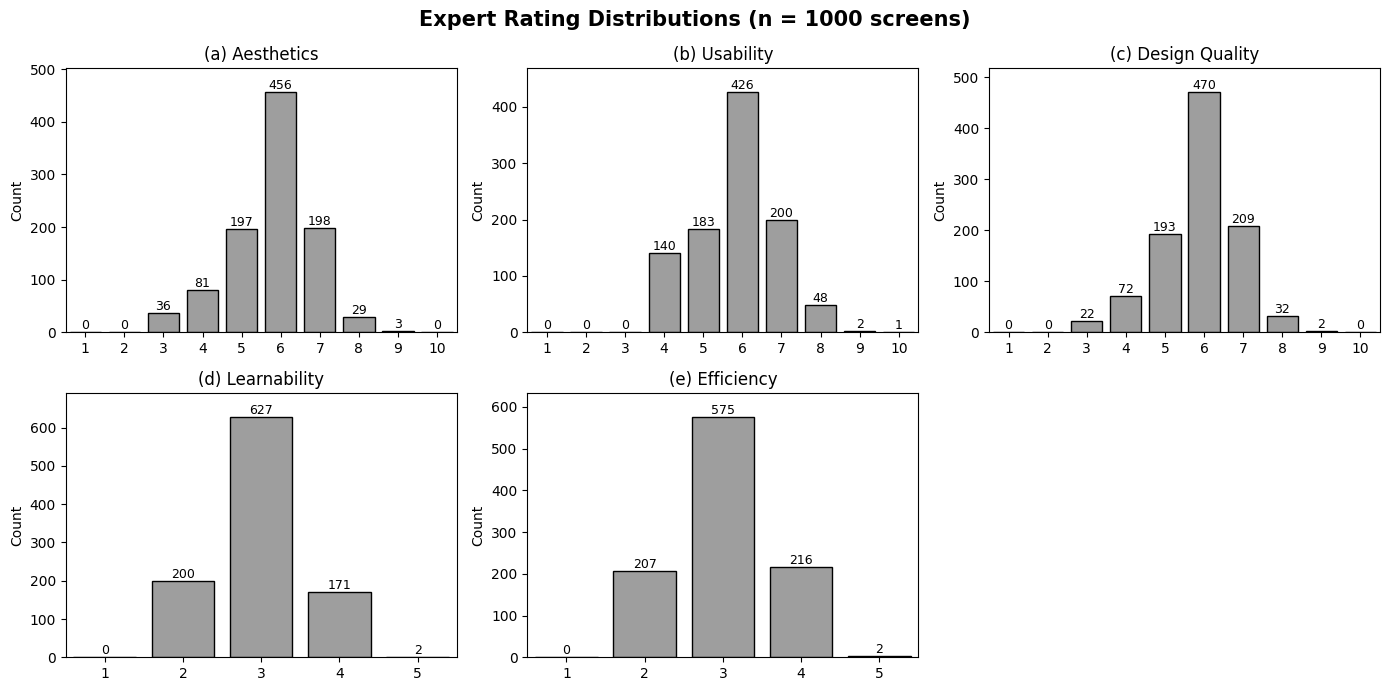

In [9]:
def plot_expert_histograms():
    fig, axes = aspect_grid(f"Expert Rating Distributions (n = {len(experts_rated)} screens)", figsize=(14, 7))
    for aspect, ax in axes.items():
        n = SCALES[aspect]
        counts = np.bincount(experts_rated[aspect].astype(int), minlength=n + 1)[1:]
        x = np.arange(1, n + 1)
        ax.bar(x, counts, color=MODEL_COLORS["Expert"], edgecolor="black")
        for xi, c in zip(x, counts):
            ax.text(xi, c, int(c), ha="center", va="bottom", fontsize=9)
        ax.set(title=panel_title(aspect), xticks=x, xlim=(0.5, n + 0.5), ylim=(0, counts.max() * 1.1), ylabel="Count")
    fig.tight_layout()
    plt.show()

plot_expert_histograms()

## 3.3 Experts vs. LLMs: Rating Distributions
Expert ratings next to every model's zero-shot (light) and few-shot (dark) ratings.
Boxes show the IQR, black lines the median and white diamonds the mean.

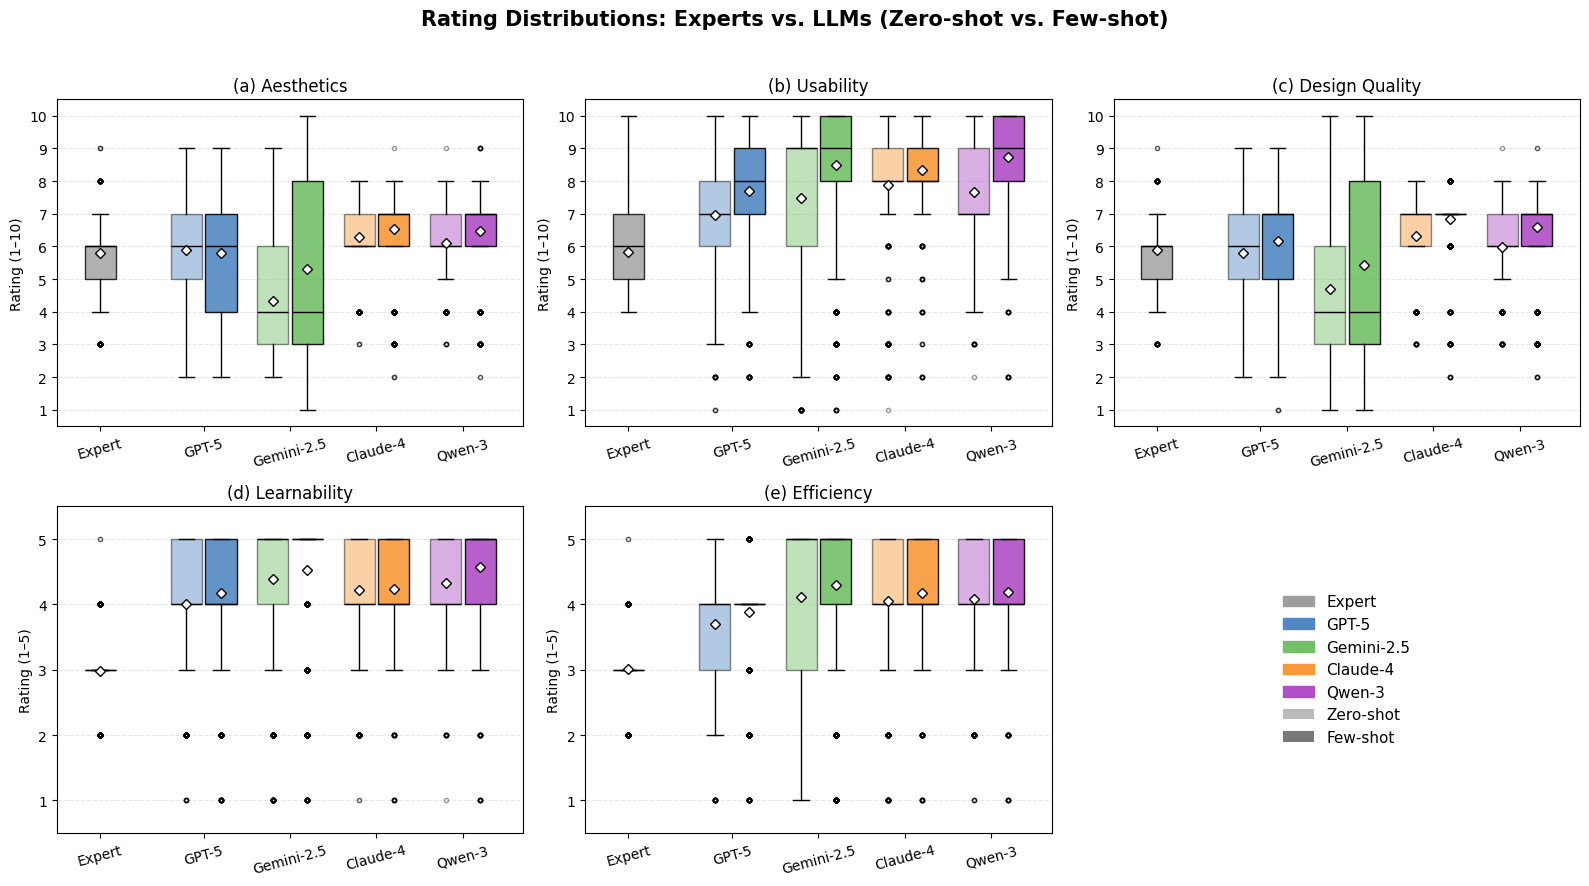

In [10]:
def plot_rating_boxplots():
    fig, axes = aspect_grid("Rating Distributions: Experts vs. LLMs (Zero-shot vs. Few-shot)",
                            legend=legend_handles(with_expert=True))
    box_w, pair_gap = 0.36, 0.2
    groups = [("Expert", "expert", 0.0)] + [
        (m, p, 1.2 + j + (k - 0.5) * 2 * pair_gap) for j, m in enumerate(MODELS) for k, p in enumerate(PROMPTINGS)]
    for aspect, ax in axes.items():
        data = scores_long[scores_long["aspect"] == aspect]
        for source, prompting, x in groups:
            vals = data.loc[(data["source"] == source) & (data["prompting"] == prompting), "score"]
            ax.boxplot(vals, positions=[x], widths=box_w, patch_artist=True, showmeans=True,
                       boxprops=dict(facecolor=MODEL_COLORS[source], alpha=PROMPT_ALPHA.get(prompting, 0.8)),
                       medianprops=dict(color="black"),
                       meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5),
                       flierprops=dict(marker="o", markersize=3, alpha=0.4))
        n = SCALES[aspect]
        ax.set_xticks([0.0] + [1.2 + j for j in range(len(MODELS))], ["Expert", *MODELS], rotation=15)
        ax.set(title=panel_title(aspect), ylim=(0.5, n + 0.5), yticks=range(1, n + 1), ylabel=f"Rating (1–{n})")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_rating_boxplots()

# 4. Bias: Do LLMs Rate Higher or Lower than Experts?

## 4.1 Wilcoxon Signed-Rank Test (LLM vs. Expert, paired by screen)
Cell value = median Δ (LLM − Expert); stars mark Wilcoxon significance. The full table is saved in Section 9.

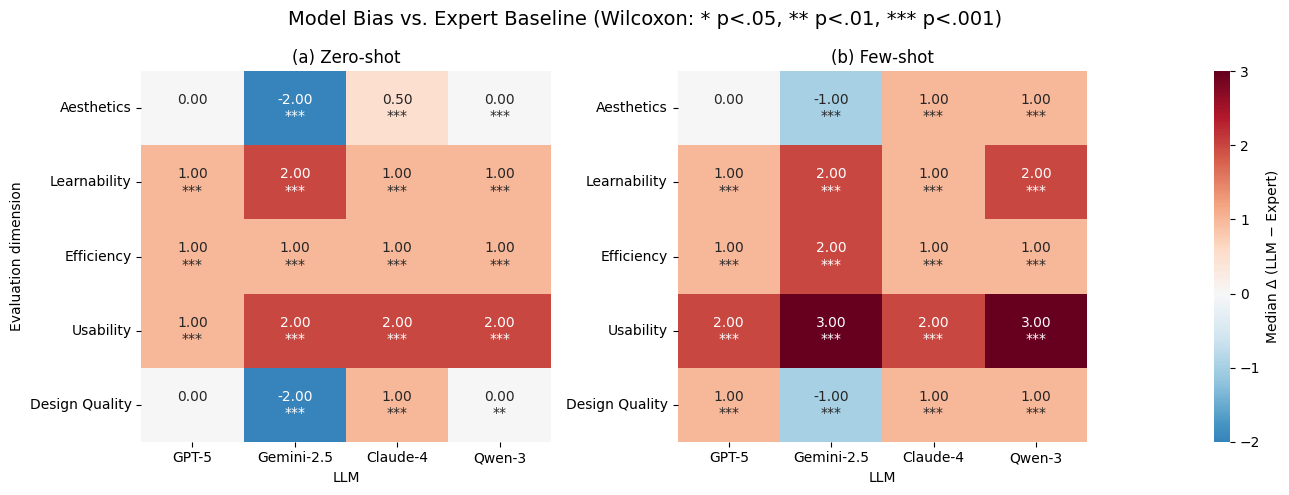

In [11]:
def wilcoxon_stats(pairs, aspect):
    W, p = wilcoxon(pairs["llm_score"], pairs["expert_score"], zero_method="wilcox")
    return {"W": W, "p_value": p, "significant": p < ALPHA,
            "median_delta": np.median(pairs["llm_score"] - pairs["expert_score"])}

wilcoxon_df = per_comparison_table(wilcoxon_stats)

def plot_bias_heatmap():
    fig, axes = plt.subplots(1, 3, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1, 0.04]})
    for i, (ax, prompting) in enumerate(zip(axes, PROMPTINGS)):
        w = wilcoxon_df[wilcoxon_df["prompting"] == prompting]
        pivot = lambda col: w.pivot(index="aspect", columns="model", values=col).reindex(index=ASPECTS, columns=list(MODELS))
        delta, p = pivot("median_delta").astype(float), pivot("p_value")
        annot = delta.map("{:.2f}".format) + "\n" + p.map(p_stars)
        sns.heatmap(delta.rename(index=ASPECT_LABELS), annot=annot.values, fmt="", cmap="RdBu_r", center=0,
                    vmin=-2, vmax=3, ax=ax, cbar=i == 1, cbar_ax=axes[2],
                    cbar_kws={"label": "Median Δ (LLM − Expert)"})
        ax.set(title=f"({string.ascii_lowercase[i]}) {PROMPT_LABELS[prompting]}", xlabel="LLM",
               ylabel="Evaluation dimension" if i == 0 else "")
    fig.suptitle("Model Bias vs. Expert Baseline (Wilcoxon: * p<.05, ** p<.01, *** p<.001)", fontsize=14)
    fig.tight_layout()
    plt.show()

plot_bias_heatmap()

## 4.2 Per-Screen Error Distribution
Each dot is one screen; black diamonds are medians.

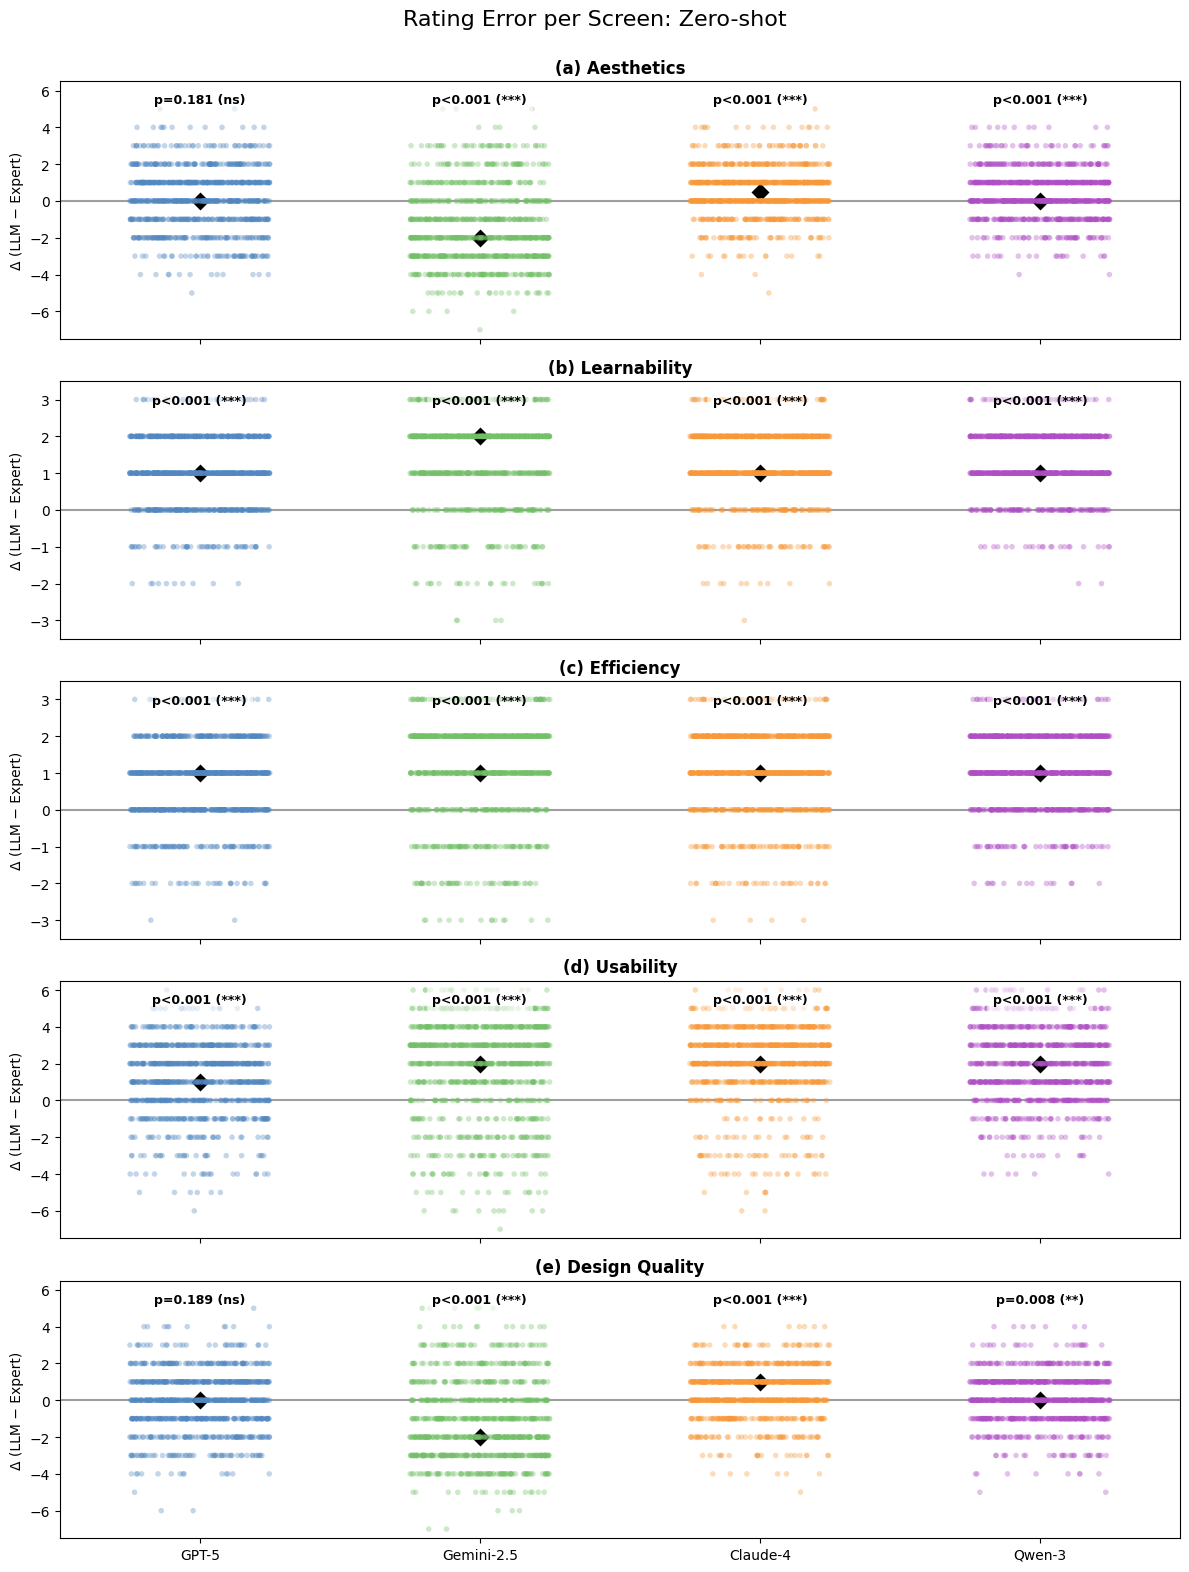

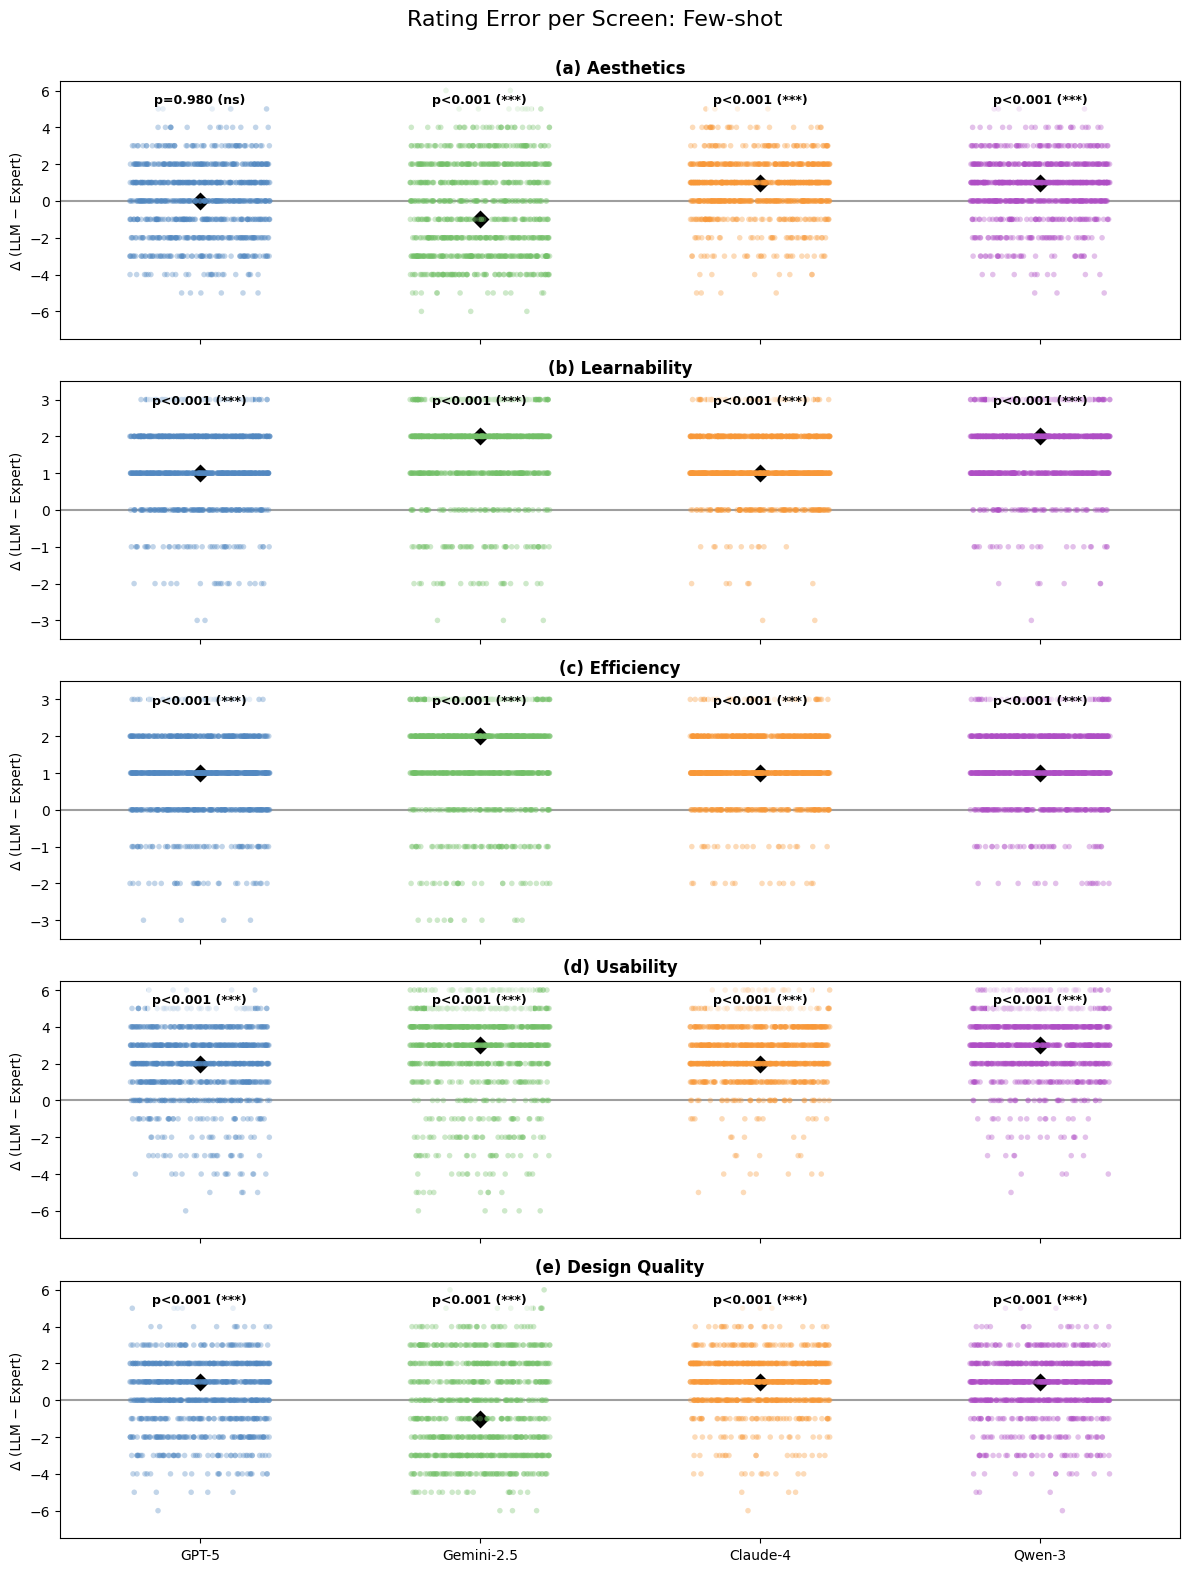

In [12]:
def plot_error_distribution(prompting):
    data = ratings_long[ratings_long["prompting"] == prompting]
    order = list(MODELS)
    fig, axes = plt.subplots(len(ASPECTS), 1, figsize=(12, 3.2 * len(ASPECTS)), sharex=True)
    for i, (ax, aspect) in enumerate(zip(axes, ASPECTS)):
        d = data[data["aspect"] == aspect]
        ax.axhline(0, color=MODEL_COLORS["Expert"], linewidth=1.5)
        sns.stripplot(data=d, x="model", y="delta", order=order, hue="model", palette=MODEL_COLORS,
                      alpha=0.35, size=4, jitter=0.25, legend=False, ax=ax)
        sns.pointplot(data=d, x="model", y="delta", order=order, color="black", estimator="median",
                      errorbar=None, markers="D", linestyle="none", ax=ax)
        ax.set_ylim(DELTA_YLIM[SCALES[aspect]])
        stats = wilcoxon_df[(wilcoxon_df["prompting"] == prompting) & (wilcoxon_df["aspect"] == aspect)].set_index("model")
        for x, model in enumerate(order):
            if model in stats.index:
                p = stats.at[model, "p_value"]
                ax.text(x, ax.get_ylim()[1] * 0.9, f"{fmt_p(p)} ({p_stars(p) or 'ns'})", ha="center", va="top",
                        fontsize=9, fontweight="bold", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
        ax.set_title(f"({string.ascii_lowercase[i]}) {ASPECT_LABELS[aspect]}", fontweight="bold")
        ax.set(xlabel="", ylabel="Δ (LLM − Expert)")
    fig.suptitle(f"Rating Error per Screen: {PROMPT_LABELS[prompting]}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

for prompting in PROMPTINGS:
    plot_error_distribution(prompting)

# 5. Overall Agreement with Experts: Brennan–Prediger κ (quadratic weights)

In [13]:
def bp_stats(pairs, aspect):
    est = CAC(pd.DataFrame({"Expert": pairs["expert_score"].values, "Model": pairs["llm_score"].values}),
              categories=CATEGORIES[aspect], weights="quadratic").bp()["est"]
    return {"bp_kappa": est["coefficient_value"], "ci_low": est["confidence_interval"][0],
            "ci_high": est["confidence_interval"][1], "p_value": est["p_value"]}

bp_df = per_comparison_table(bp_stats)
by_model_prompting(bp_df, "bp_kappa", "{:.3f}")

aspect               Aesthetics Learnability Efficiency Usability  \
GPT-5      Zero-shot      0.835        0.498      0.605     0.694   
           Few-shot       0.774        0.360      0.523     0.561   
Gemini-2.5 Zero-shot      0.622        0.153      0.207     0.420   
           Few-shot       0.617        0.067      0.187     0.229   
Claude-4   Zero-shot      0.879        0.377      0.388     0.502   
           Few-shot       0.827        0.416      0.456     0.479   
Qwen-3     Zero-shot      0.889        0.344      0.452     0.585   
           Few-shot       0.817        0.154      0.411     0.312   

aspect               Design Quality  
GPT-5      Zero-shot          0.844  
           Few-shot           0.791  
Gemini-2.5 Zero-shot          0.636  
           Few-shot           0.595  
Claude-4   Zero-shot          0.879  
           Few-shot           0.816  
Qwen-3     Zero-shot          0.888  
           Few-shot           0.815

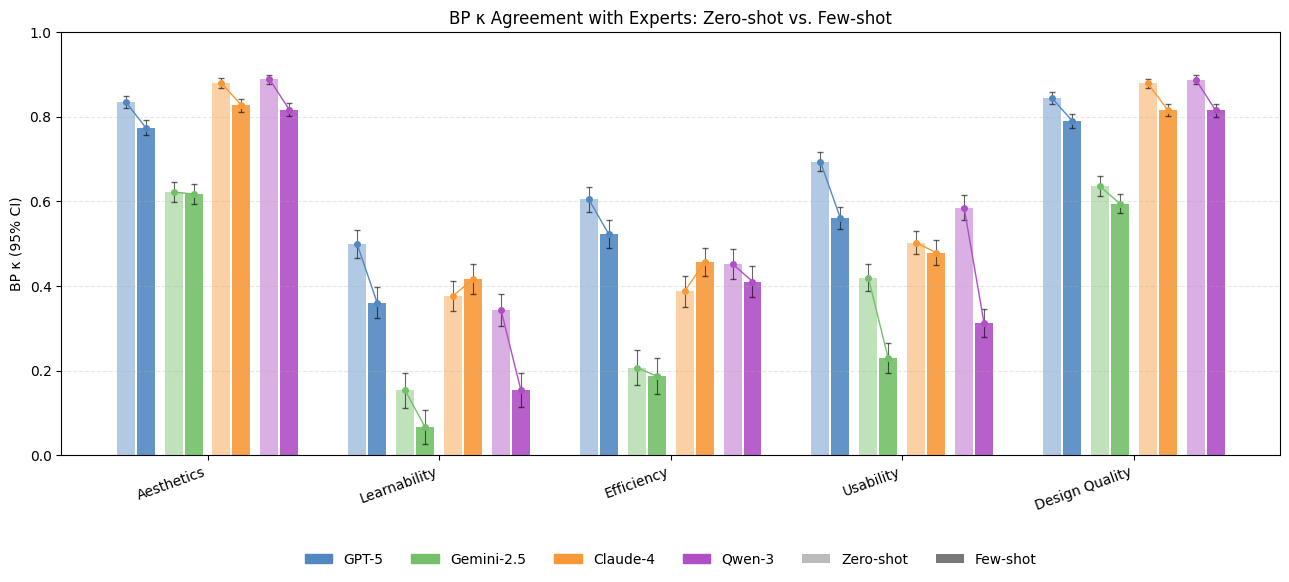

In [14]:
def plot_prompting_bars(ax, df, value, aspects, ylabel, ylim, title, ci=None):
    """Per aspect and model: zero-shot bar (light) next to few-shot bar (dark), joined by a line."""
    w, gap_pair, gap_model, gap_aspect = 0.18, 0.02, 0.10, 0.50
    vals = df.set_index(["prompting", "model", "aspect"])
    block = len(MODELS) * (2 * w + gap_pair) + (len(MODELS) - 1) * gap_model
    centers = []
    for i, aspect in enumerate(aspects):
        base = i * (block + gap_aspect)
        centers.append(base + block / 2 - w / 2)
        for j, model in enumerate(MODELS):
            xs = [base + j * (2 * w + gap_pair + gap_model) + k * (w + gap_pair) for k in range(2)]
            rows = [vals.loc[(p, model, aspect)] for p in PROMPTINGS]
            for x, row, p in zip(xs, rows, PROMPTINGS):
                yerr = [[row[value] - row[ci[0]]], [row[ci[1]] - row[value]]] if ci else None
                ax.bar(x, row[value], width=w, color=MODEL_COLORS[model], alpha=PROMPT_ALPHA[p],
                       yerr=yerr, error_kw=dict(elinewidth=0.8, capsize=2, alpha=0.6))
            ax.plot(xs, [r[value] for r in rows], marker="o", markersize=4, color=MODEL_COLORS[model], linewidth=1)
    ax.set_xticks(centers, [ASPECT_LABELS[a] for a in aspects], rotation=20, ha="right")
    ax.set(title=title, ylabel=ylabel, ylim=ylim)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig, ax = plt.subplots(figsize=(13, 6))
plot_prompting_bars(ax, bp_df, "bp_kappa", ASPECTS, "BP κ (95% CI)", (0, 1),
                    "BP κ Agreement with Experts: Zero-shot vs. Few-shot", ci=("ci_low", "ci_high"))
ax.legend(handles=legend_handles(), loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=6, frameon=False)
fig.tight_layout()
plt.show()

# 6. Where Do the Models Fail?
κ summarises agreement over all screens. This section breaks the error down by
**how good the screen is** (expert score), **how many issues the experts found** and **app category**,
and finally shows the screens all models get most wrong.

## 6.1 Calibration: Mean LLM Rating per Expert Score
A perfectly calibrated model follows the dashed diagonal. A flat line means the model gives similar ratings
regardless of quality, over-rating poor screens and under-rating good ones. Grey bars show how many screens
have each expert score; points with fewer than 5 screens are hidden.

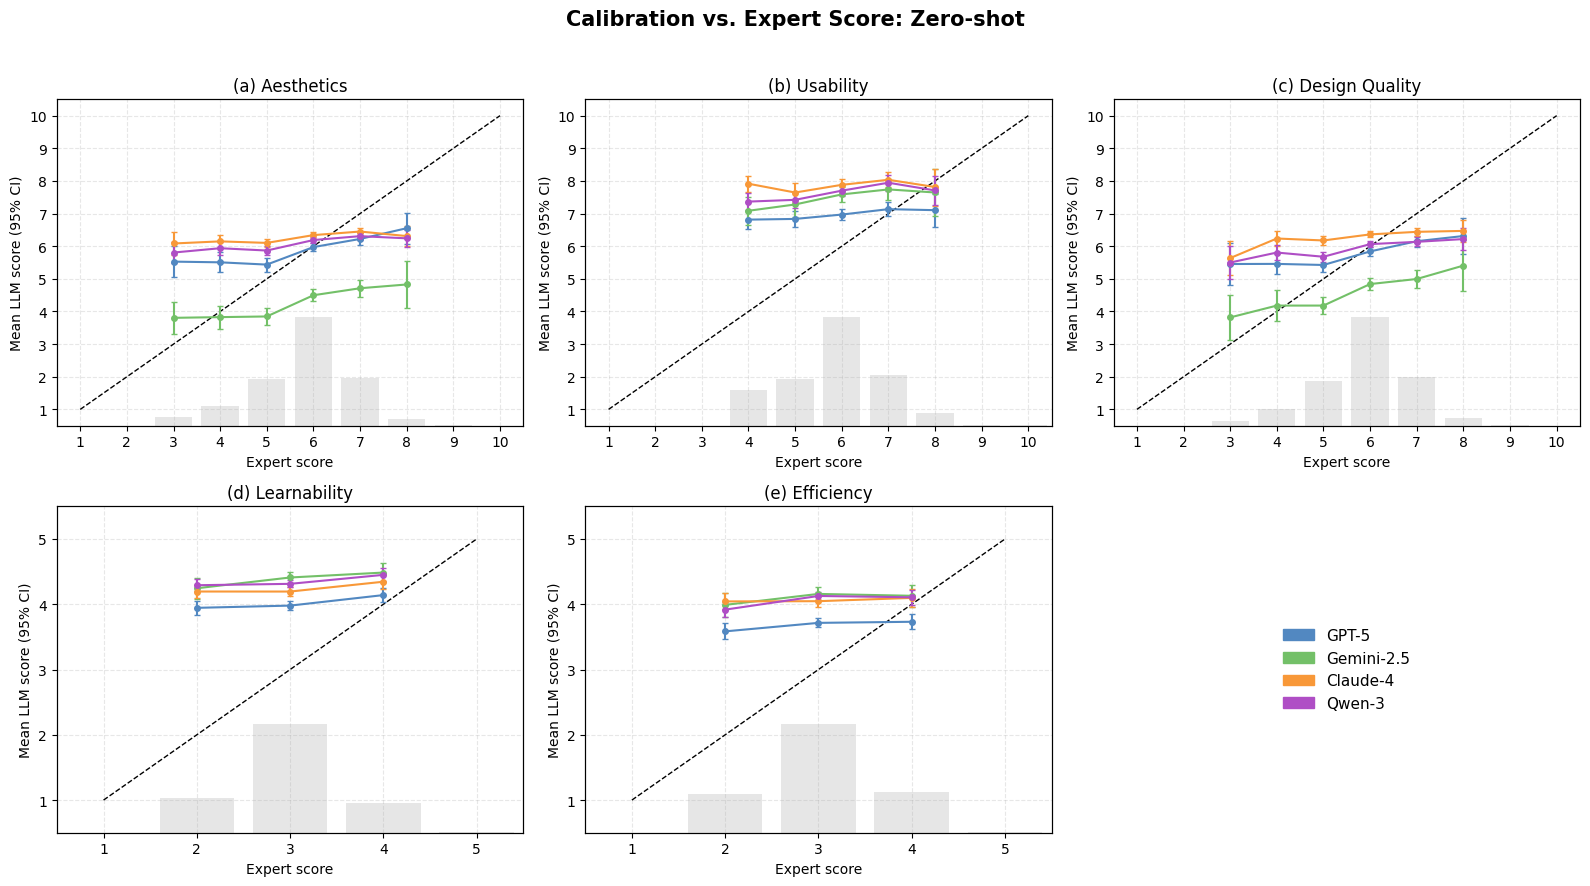

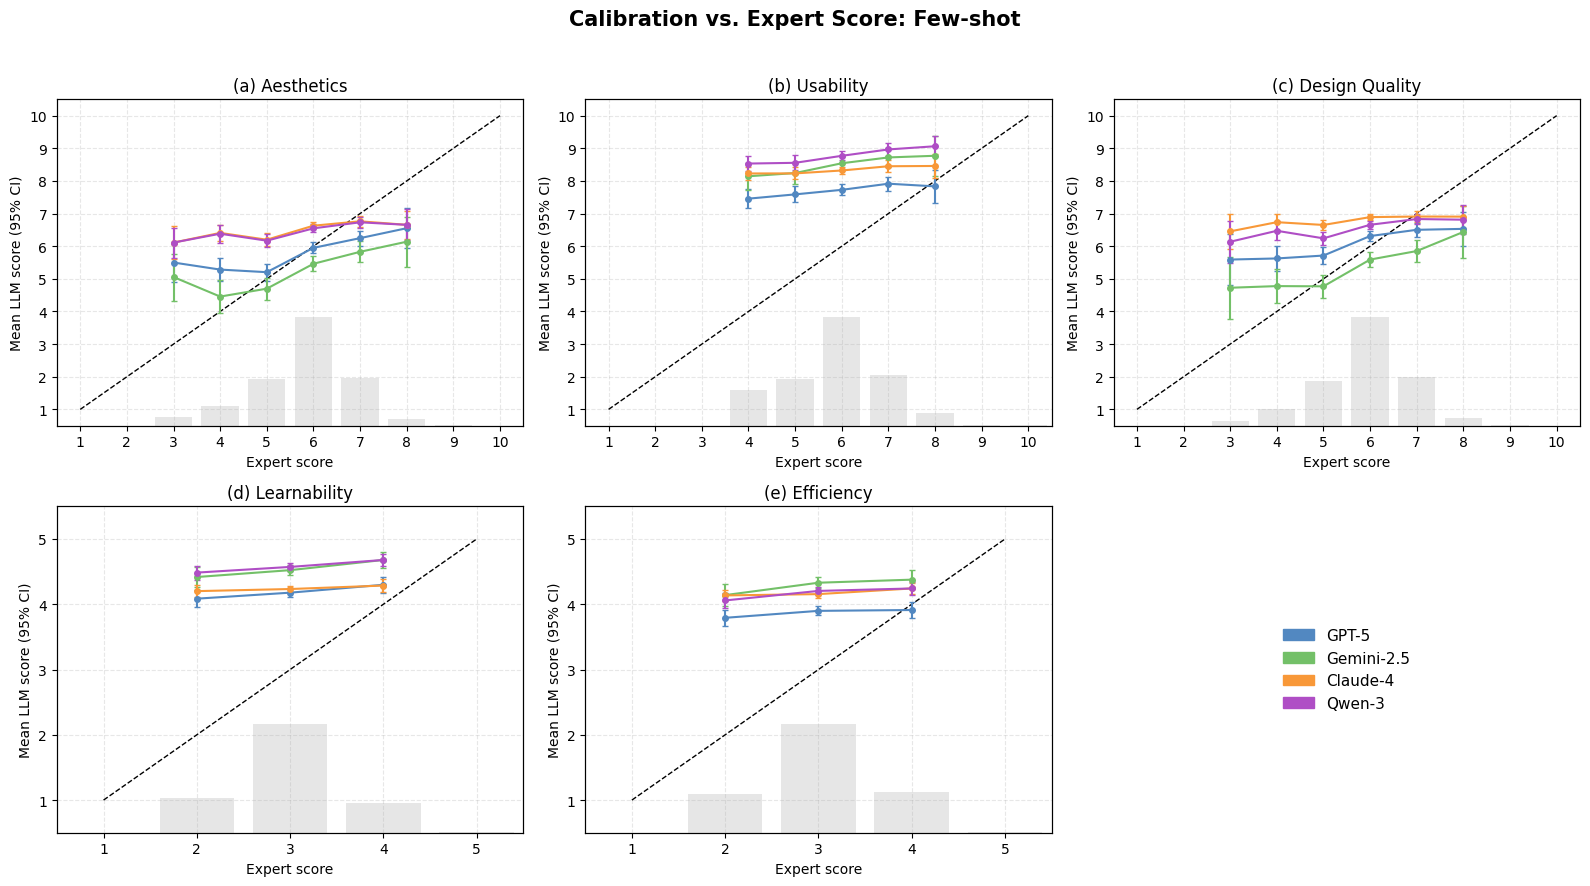

In [15]:
def plot_calibration(prompting, min_n=5):
    fig, axes = aspect_grid(f"Calibration vs. Expert Score: {PROMPT_LABELS[prompting]}",
                            legend=legend_handles(with_prompting=False))
    data = ratings_long[ratings_long["prompting"] == prompting].dropna(subset=["llm_score"])
    for aspect, ax in axes.items():
        n = SCALES[aspect]
        d = data[data["aspect"] == aspect]
        counts = experts_rated[aspect].value_counts().reindex(range(1, n + 1), fill_value=0)
        bars = ax.twinx()
        bars.bar(counts.index, counts.values, color=MODEL_COLORS["Expert"], alpha=0.25, width=0.8)
        bars.set(ylim=(0, counts.max() * 3), yticks=[])
        ax.set_zorder(bars.get_zorder() + 1)
        ax.patch.set_visible(False)
        ax.plot([1, n], [1, n], linestyle="--", color="black", linewidth=1)
        for model in MODELS:
            g = d[d["model"] == model].groupby("expert_score")["llm_score"].agg(["mean", "sem", "count"])
            g = g[g["count"] >= min_n]
            ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], marker="o", markersize=4, capsize=2,
                        color=MODEL_COLORS[model], linewidth=1.5)
        ax.set(title=panel_title(aspect), xlim=(0.5, n + 0.5), ylim=(0.5, n + 0.5), xticks=range(1, n + 1),
               yticks=range(1, n + 1), xlabel="Expert score", ylabel="Mean LLM score (95% CI)")
        ax.grid(linestyle="--", alpha=0.3)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

for prompting in PROMPTINGS:
    plot_calibration(prompting)

## 6.2 Error by Expert-Score Bin (Low / Mid / High)
Mean absolute error per bin, then the share of LLM ratings that land below, in, or above the expert's bin.
A bin without expert scores gets no column (e.g. Usability "Low" in the 1000-task subset: no screen there got an expert usability score of 1–3).

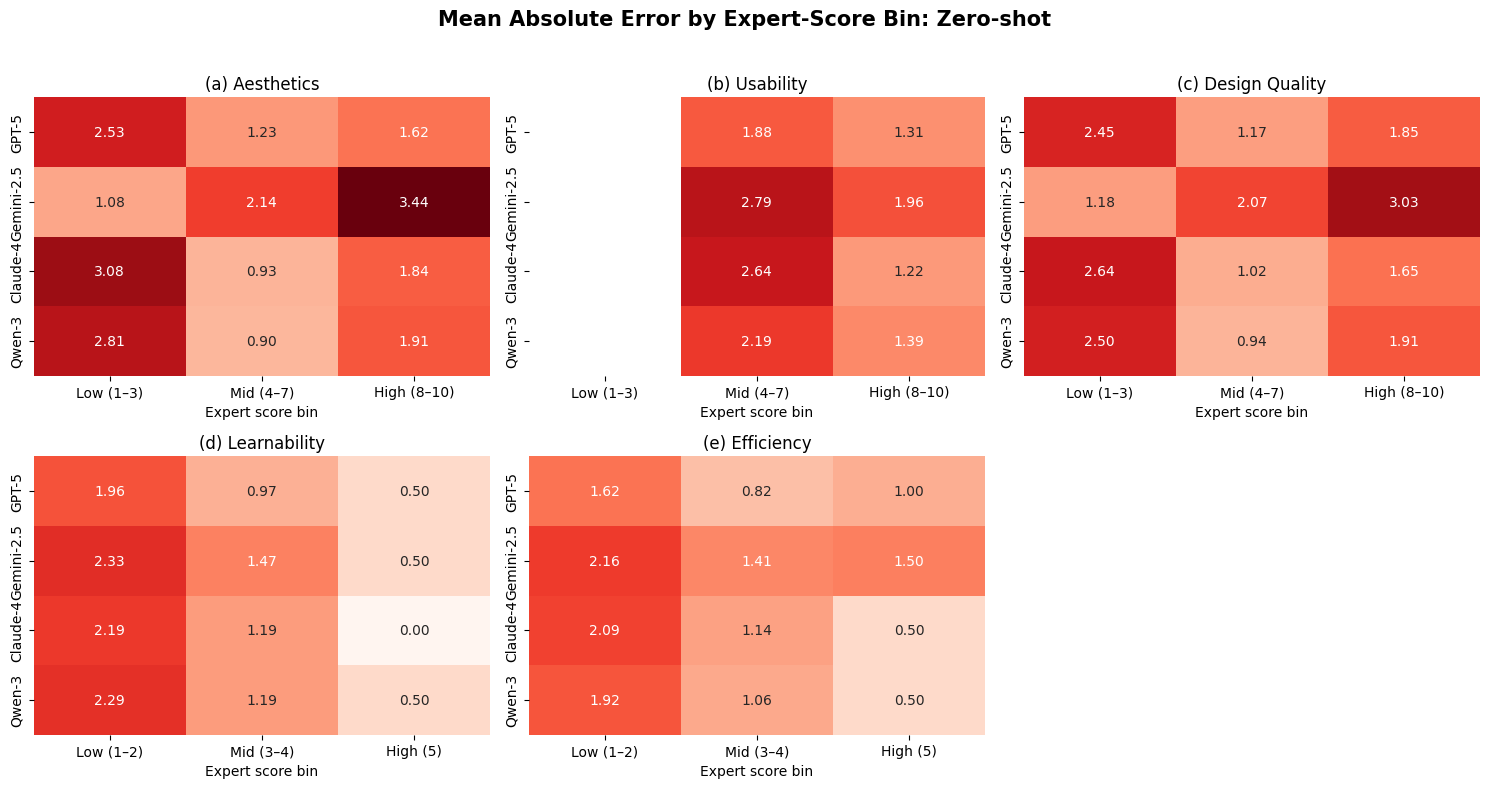

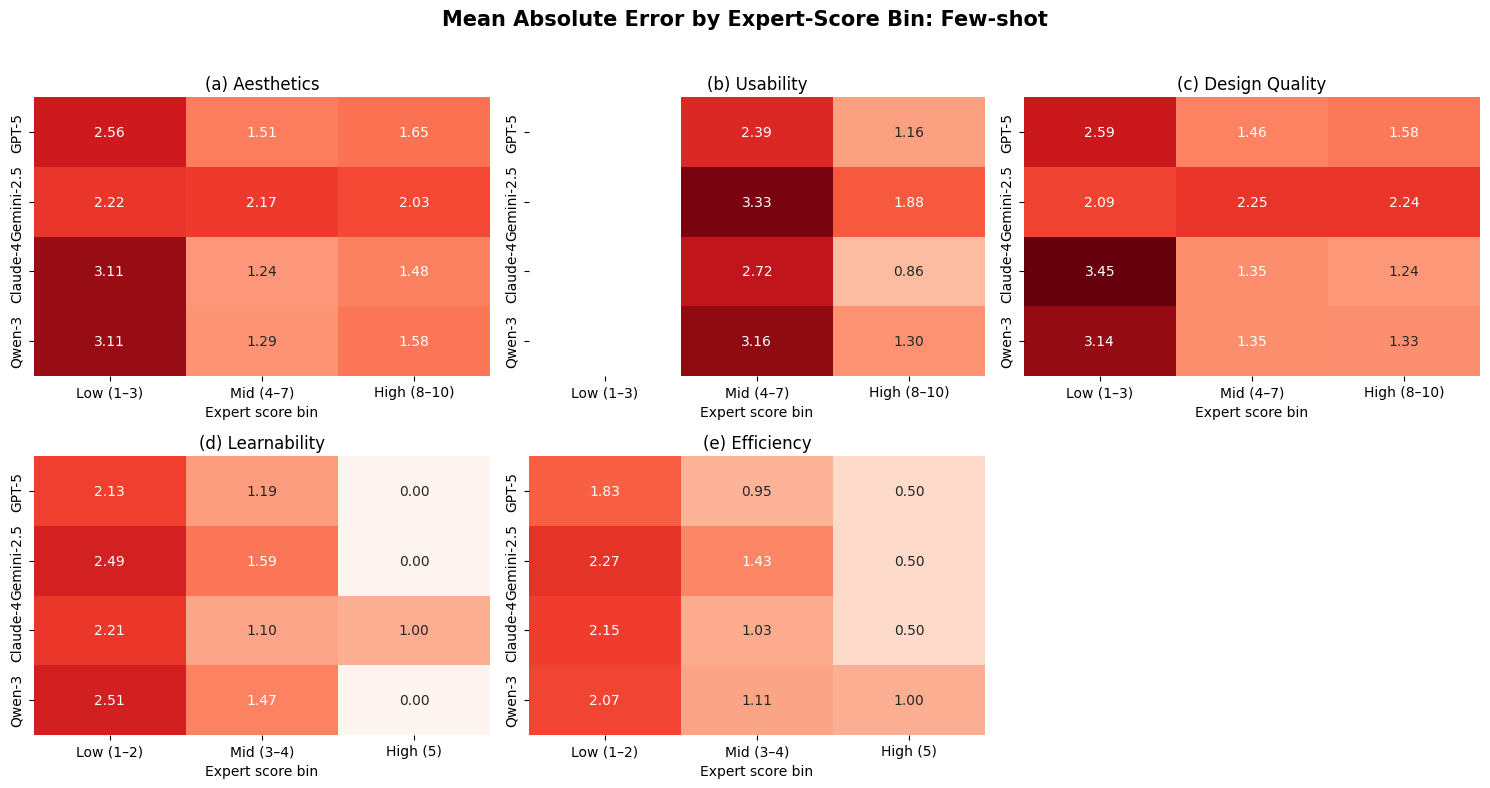

In [16]:
def with_expert_bins(df):
    """Add the expert-score bin (Low/Mid/High) and whether the LLM's bin is below/same/above it."""
    parts = []
    for aspect, d in df.groupby("aspect"):
        bins, labels = SCORE_BINS[SCALES[aspect]]
        to_bin = lambda s: pd.cut(s.astype(int), bins=bins, labels=False, include_lowest=True)
        parts.append(d.assign(bin=pd.Categorical.from_codes(to_bin(d["expert_score"]), labels),
                              bin_shift=np.sign(to_bin(d["llm_score"]) - to_bin(d["expert_score"]))
                                        .map({-1: "below", 0: "same", 1: "above"})))
    return pd.concat(parts)

binned = with_expert_bins(ratings_long.dropna(subset=["llm_score"]))
mae_bin_df = (binned.assign(abs_err=binned["delta"].abs().astype(float))
              .groupby(["prompting", "aspect", "model", "bin"], observed=True)["abs_err"]
              .agg(mae="mean", n="count").reset_index())

def plot_mae_by_bin(prompting):
    fig, axes = aspect_grid(f"Mean Absolute Error by Expert-Score Bin: {PROMPT_LABELS[prompting]}", figsize=(15, 8))
    vmax = mae_bin_df["mae"].max()
    for aspect, ax in axes.items():
        d = mae_bin_df[(mae_bin_df["prompting"] == prompting) & (mae_bin_df["aspect"] == aspect)]
        heat = d.pivot(index="model", columns="bin", values="mae").reindex(
            index=list(MODELS), columns=SCORE_BINS[SCALES[aspect]][1])
        sns.heatmap(heat, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=vmax, cbar=False, ax=ax)
        ax.set(title=panel_title(aspect), xlabel="Expert score bin", ylabel="")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

for prompting in PROMPTINGS:
    plot_mae_by_bin(prompting)

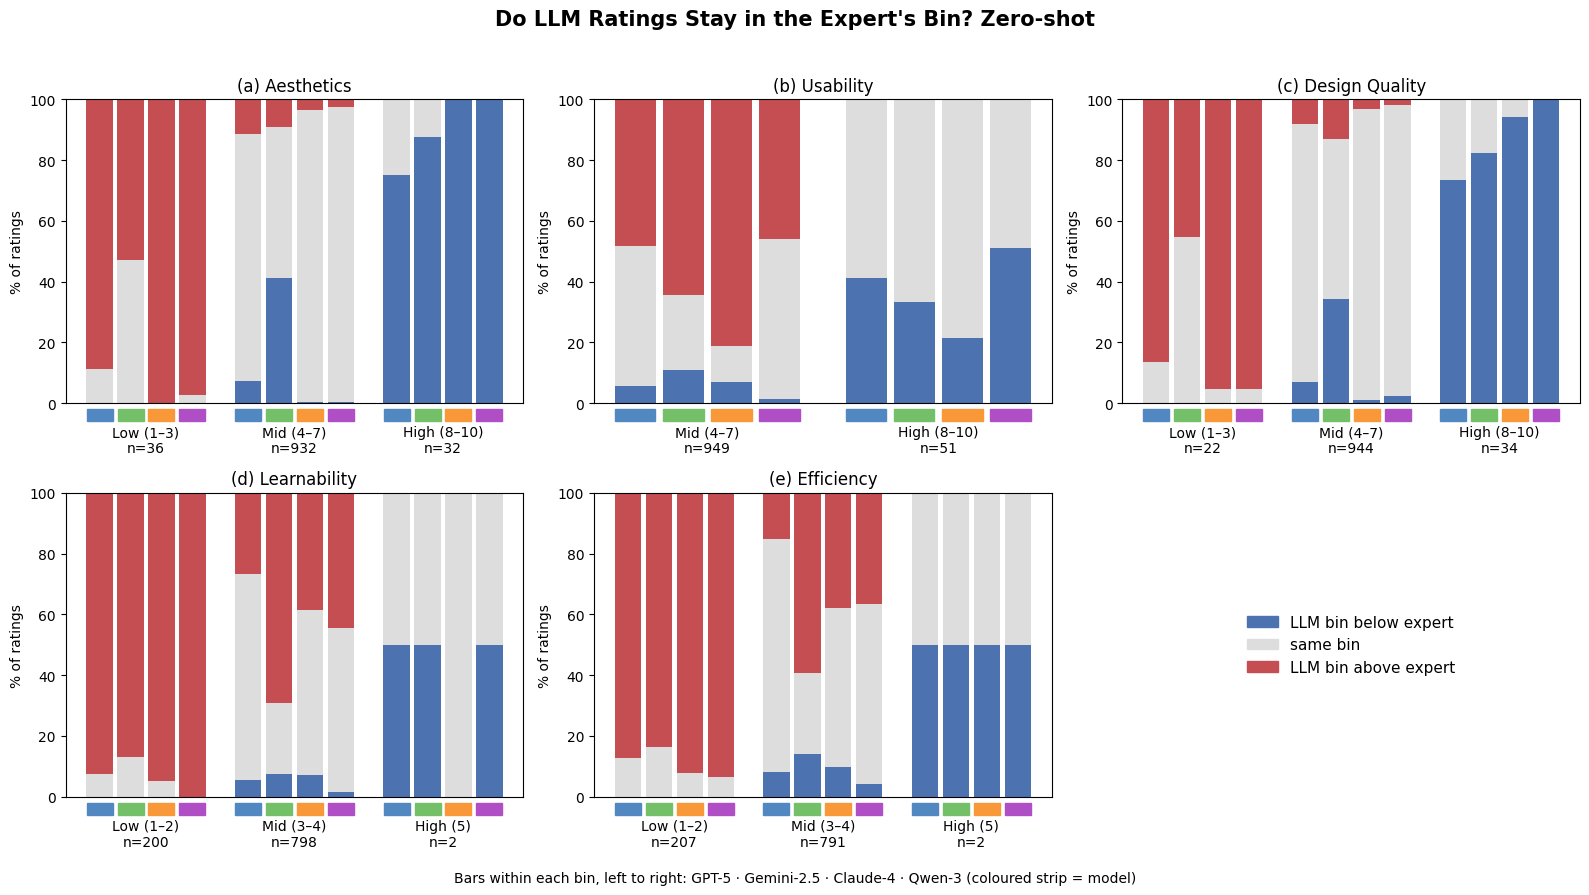

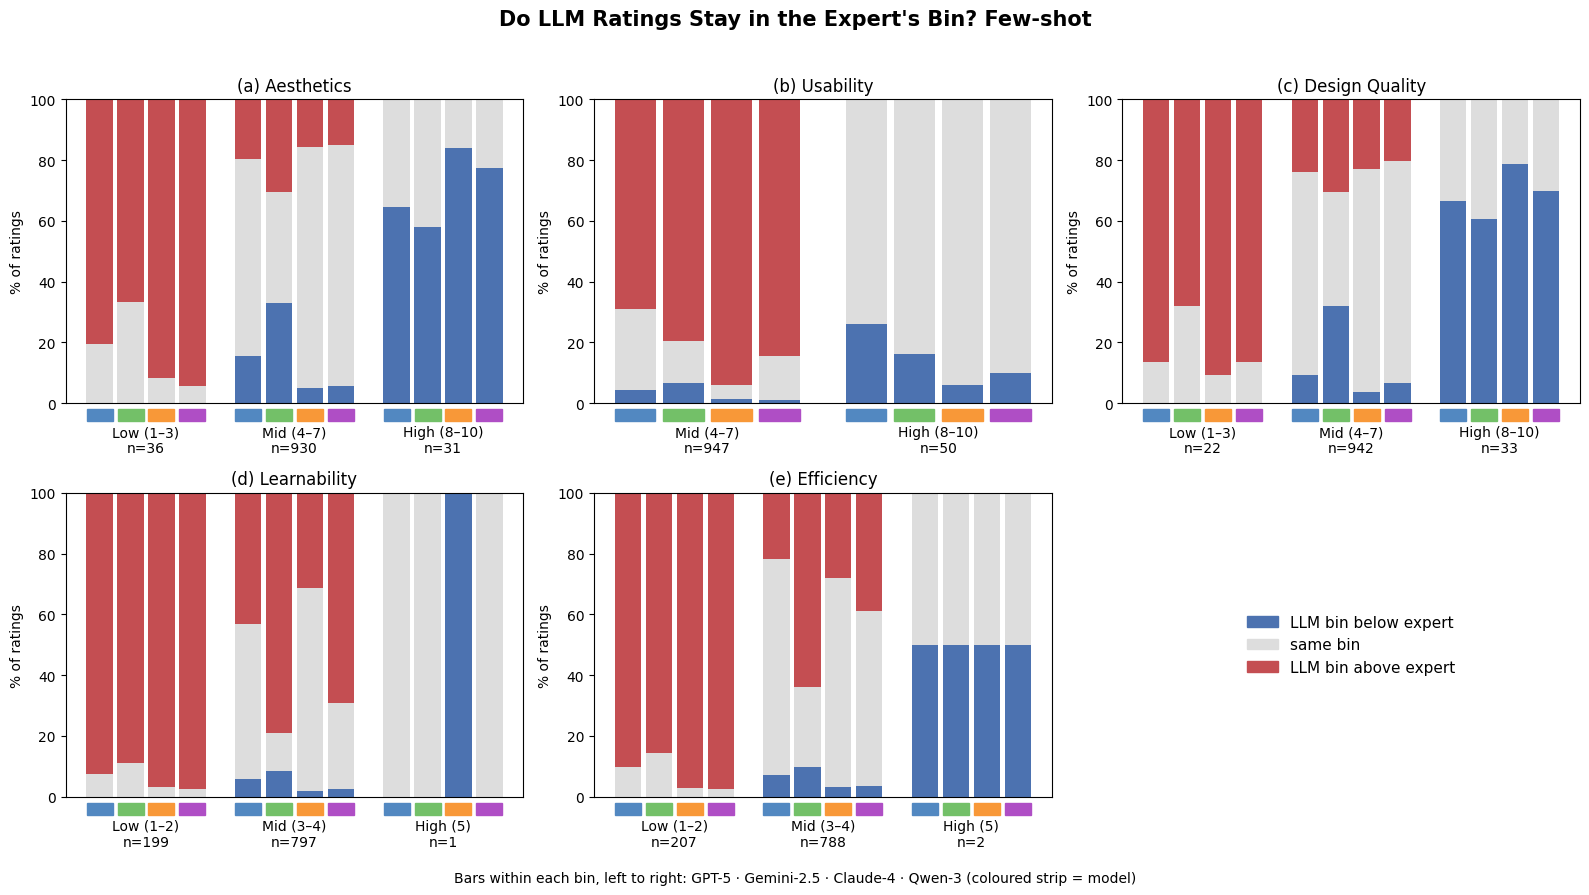

In [17]:
bin_shift_df = (binned.groupby(["prompting", "model", "aspect", "bin"], observed=True)["bin_shift"]
                .value_counts(normalize=True).mul(100).unstack(fill_value=0)[list(SHIFT_COLORS)])

binned_counts = binned.drop_duplicates(["prompting", "aspect", "screen_task_id"]).groupby(
    ["prompting", "aspect", "bin"], observed=True).size()

def plot_bin_shift(prompting):
    """Stacked bars per expert bin and model: share of LLM ratings below / in / above the expert's bin."""
    legend = [Patch(color=c, label=f"LLM bin {s} expert" if s != "same" else "same bin") for s, c in SHIFT_COLORS.items()]
    fig, axes = aspect_grid(f"Do LLM Ratings Stay in the Expert's Bin? {PROMPT_LABELS[prompting]}", legend=legend)
    d = bin_shift_df.loc[prompting]
    for aspect, ax in axes.items():
        x, ticks, model_ticks = 0, [], []
        for b in SCORE_BINS[SCALES[aspect]][1]:
            start = x
            for model in MODELS:
                if (model, aspect, b) in d.index:
                    shares = d.loc[(model, aspect, b)]
                    ax.bar(x, shares, bottom=shares.cumsum() - shares, color=list(SHIFT_COLORS.values()), width=0.85)
                    model_ticks.append((x, MODEL_COLORS[model]))
                    x += 1
            if x > start:
                n_screens = binned_counts.get((prompting, aspect, b), 0)
                ticks.append(((start + x - 1) / 2, f"{b}\nn={n_screens}"))
            x += 0.8
        ax.set_xticks(*zip(*ticks))
        ax.tick_params(axis="x", length=0, pad=16)
        for xm, color in model_ticks:   # coloured strip under each bar identifies the model
            ax.add_patch(plt.Rectangle((xm - 0.42, -6), 0.84, 4, color=color, clip_on=False))
        ax.set(title=panel_title(aspect), ylabel="% of ratings", ylim=(0, 100))
    fig.text(0.5, 0.01, "Bars within each bin, left to right: " + " · ".join(MODELS) + " (coloured strip = model)",
             ha="center", fontsize=10)
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

for prompting in PROMPTINGS:
    plot_bin_shift(prompting)

## 6.3 Bias vs. Number of Expert-Flagged Issues
Screens where the experts wrote more critique comments get lower expert ratings (dotted grey line, relative to
screens with ≤1 issue). If an LLM's Δ grows with the number of issues, the model is missing problems the experts saw.

Screens per issue count: {'≤1': 304, '2': 102, '3': 138, '4': 134, '≥5': 322}


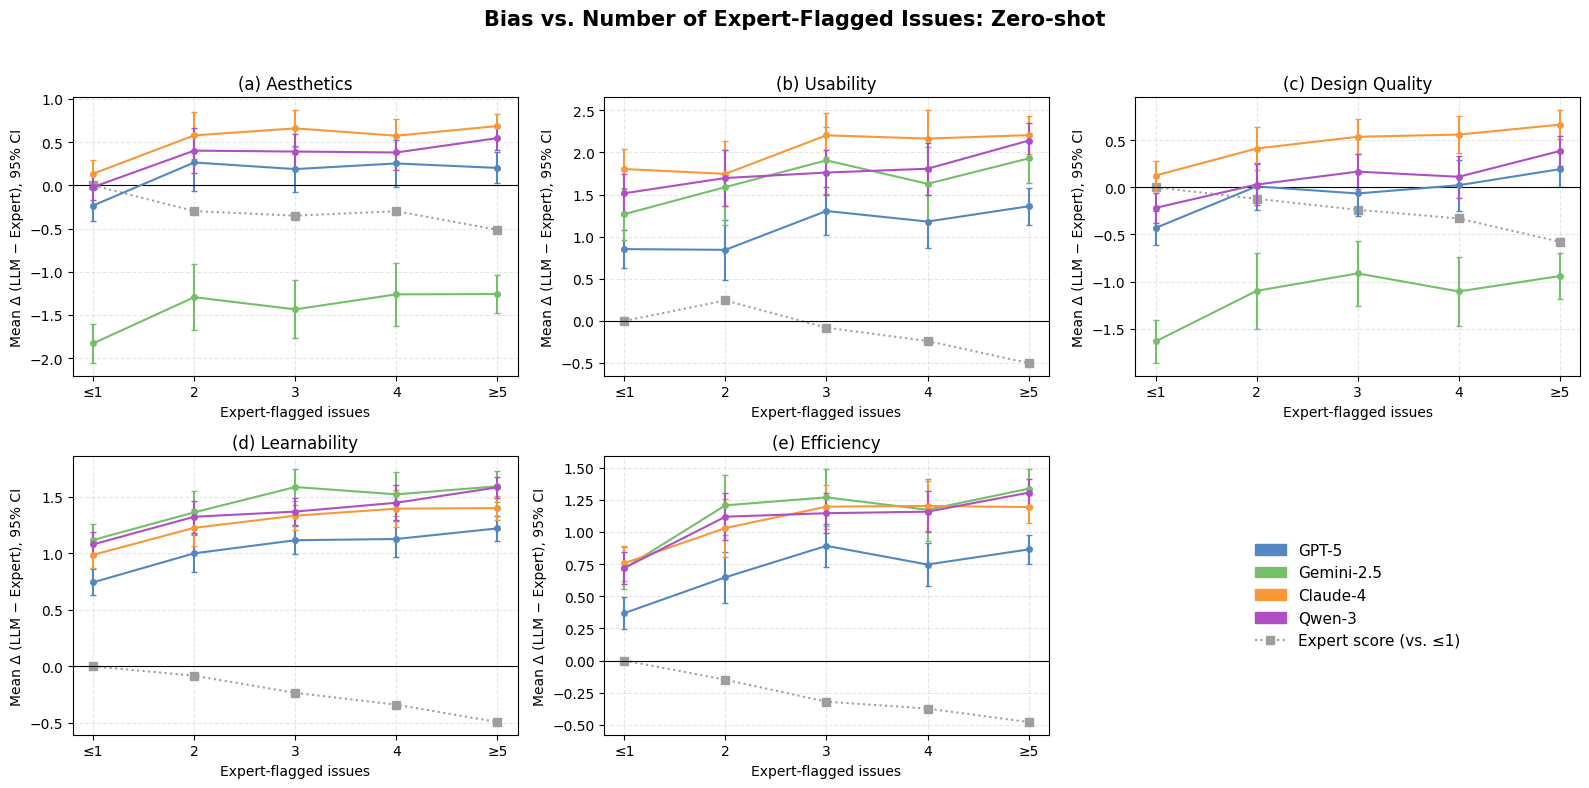

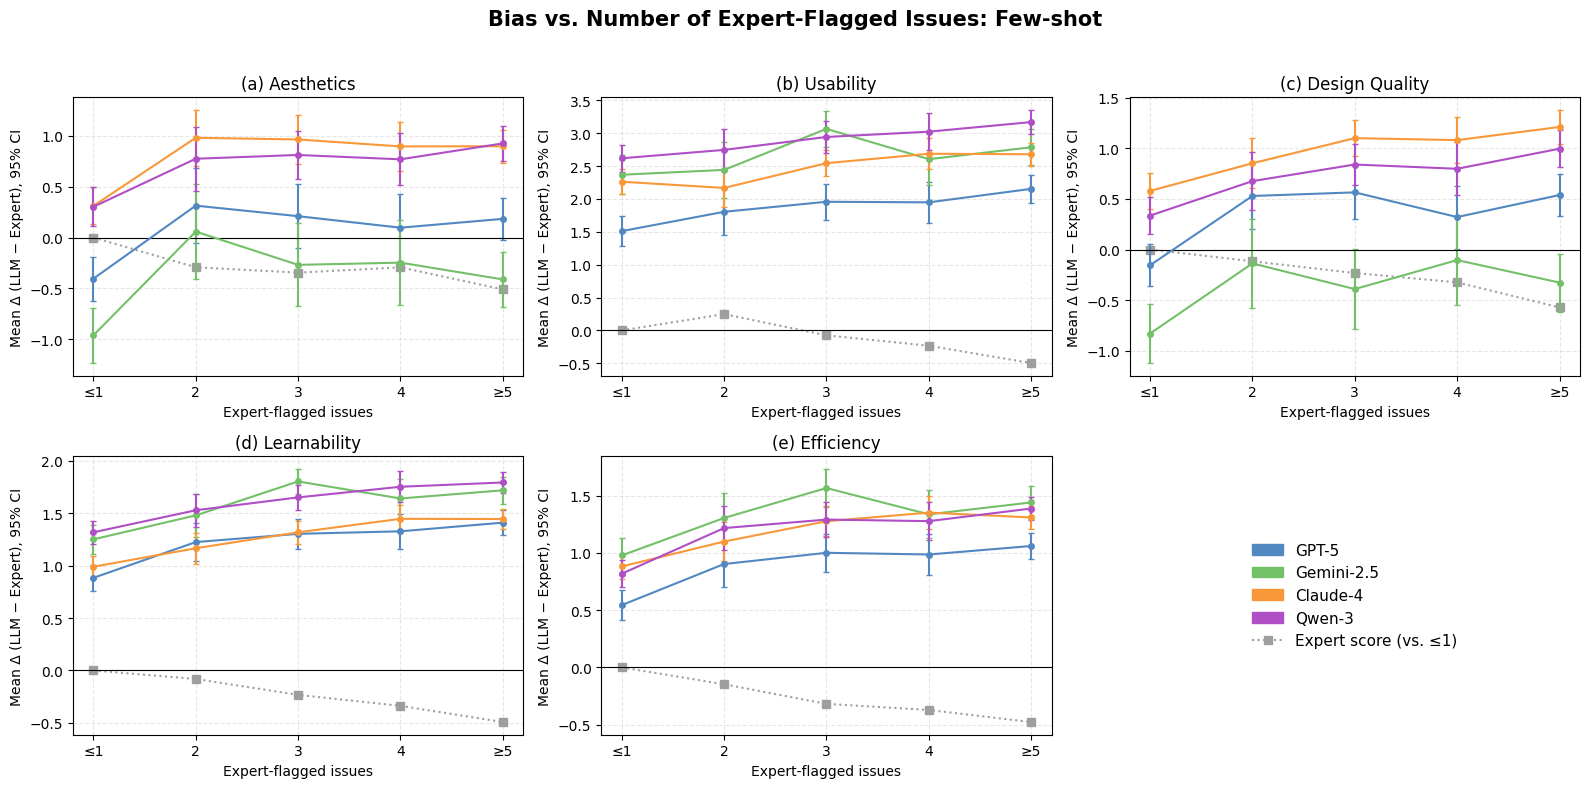

In [18]:
issue_levels = screen_meta["n_issues"].clip(1, 5)
screen_meta["issue_bucket"] = pd.Categorical(issue_levels.map({1: "≤1", 5: "≥5"}).fillna(issue_levels.astype(str)),
                                             ["≤1", "2", "3", "4", "≥5"], ordered=True)
print("Screens per issue count:", screen_meta["issue_bucket"].value_counts(sort=False).to_dict())
issues_long = ratings_long.merge(screen_meta[["screen_task_id", "issue_bucket"]], on="screen_task_id")

def plot_error_vs_issues(prompting):
    legend = [*legend_handles(with_prompting=False),
              plt.Line2D([], [], color=MODEL_COLORS["Expert"], linestyle=":", marker="s", label="Expert score (vs. ≤1)")]
    fig, axes = aspect_grid(f"Bias vs. Number of Expert-Flagged Issues: {PROMPT_LABELS[prompting]}",
                            legend=legend, figsize=(16, 8))
    d = issues_long[issues_long["prompting"] == prompting].dropna(subset=["delta"])
    for aspect, ax in axes.items():
        a = d[d["aspect"] == aspect]
        expert = a.drop_duplicates("screen_task_id").groupby("issue_bucket", observed=True)["expert_score"].mean()
        ax.plot(expert.index.astype(str), expert - expert.iloc[0], color=MODEL_COLORS["Expert"], linestyle=":", marker="s")
        for model in MODELS:
            g = a[a["model"] == model].groupby("issue_bucket", observed=True)["delta"].agg(["mean", "sem"])
            ax.errorbar(g.index.astype(str), g["mean"], yerr=1.96 * g["sem"], marker="o", markersize=4,
                        capsize=2, color=MODEL_COLORS[model])
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set(title=panel_title(aspect), xlabel="Expert-flagged issues", ylabel="Mean Δ (LLM − Expert), 95% CI")
        ax.grid(linestyle="--", alpha=0.3)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

for prompting in PROMPTINGS:
    plot_error_vs_issues(prompting)

## 6.4 Error by App Category
Mean absolute error as % of the rating scale (|Δ| / (scale − 1)), averaged over the five aspects so that
1–10 and 1–5 aspects are comparable. Categories with fewer than `MIN_CATEGORY_SCREENS` screens are pooled into "Other".

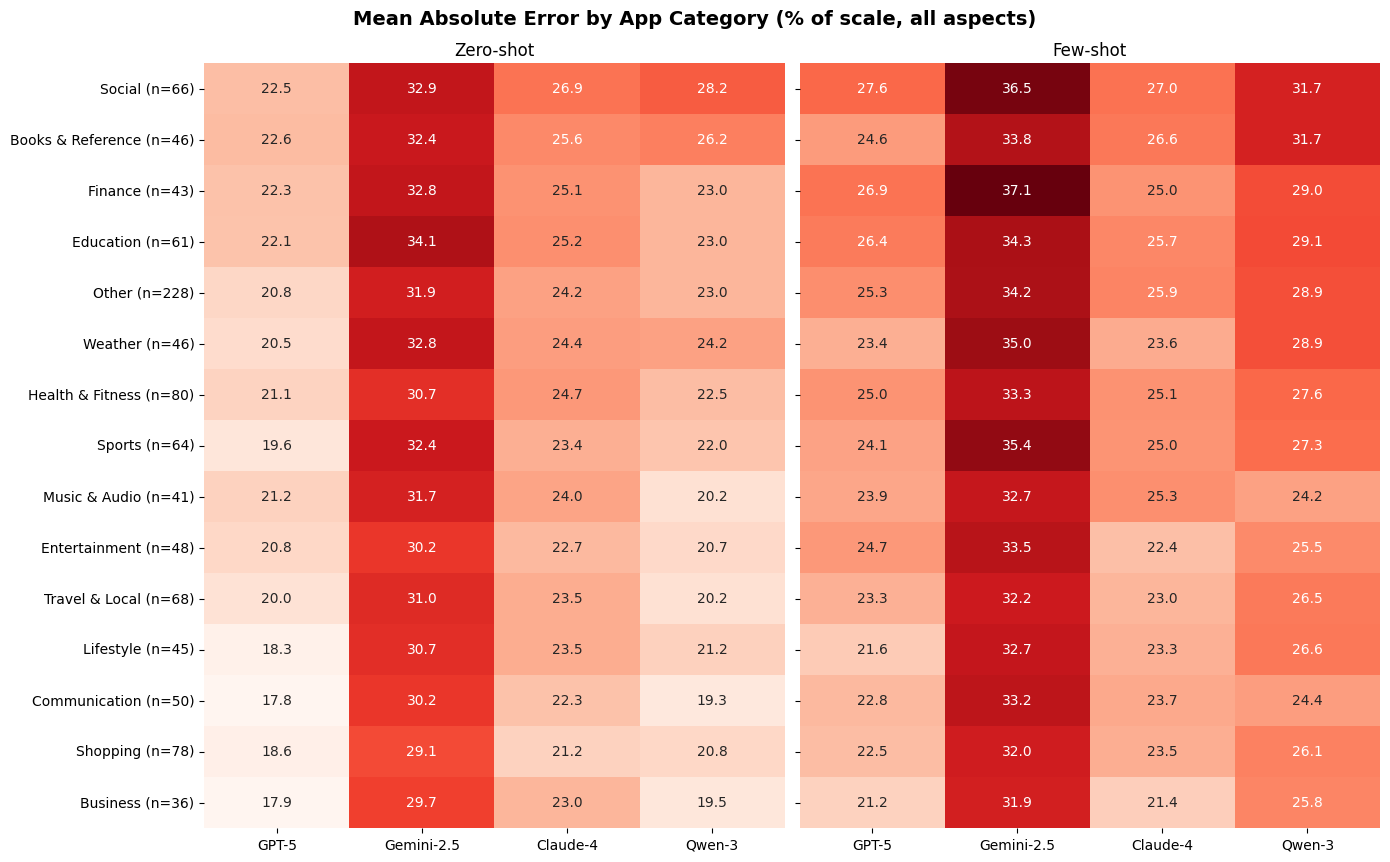

In [19]:
cat_counts = screen_meta["app_category"].value_counts()
screen_meta["category"] = screen_meta["app_category"].where(
    screen_meta["app_category"].map(cat_counts) >= MIN_CATEGORY_SCREENS, "Other")

norm_err = ratings_long.dropna(subset=["delta"]).merge(screen_meta[["screen_task_id", "category"]], on="screen_task_id")
norm_err["norm_abs_err"] = 100 * norm_err["delta"].abs().astype(float) / (norm_err["aspect"].map(SCALES) - 1)
category_err = norm_err.pivot_table(index="category", columns=["prompting", "model"], values="norm_abs_err")

def plot_category_error():
    order = category_err.mean(axis=1).sort_values(ascending=False).index
    n = screen_meta["category"].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 0.45 * len(order) + 2), sharey=True)
    for ax, prompting in zip(axes, PROMPTINGS):
        heat = category_err[prompting].reindex(index=order, columns=list(MODELS))
        sns.heatmap(heat.rename(index=lambda c: f"{c} (n={n[c]})"), annot=True, fmt=".1f", cmap="Reds",
                    vmin=category_err.values.min(), vmax=category_err.values.max(), cbar=False, ax=ax)
        ax.set(title=PROMPT_LABELS[prompting], xlabel="", ylabel="")
    fig.suptitle("Mean Absolute Error by App Category (% of scale, all aspects)", fontsize=14, weight="bold")
    fig.tight_layout()
    plt.show()

plot_category_error()

## 6.5 Consensus Failures: Screens All Models Get Wrong (zero-shot)
Screens ranked by the error averaged over models and aspects (% of scale). The table shows the expert score
and the mean LLM score per aspect.

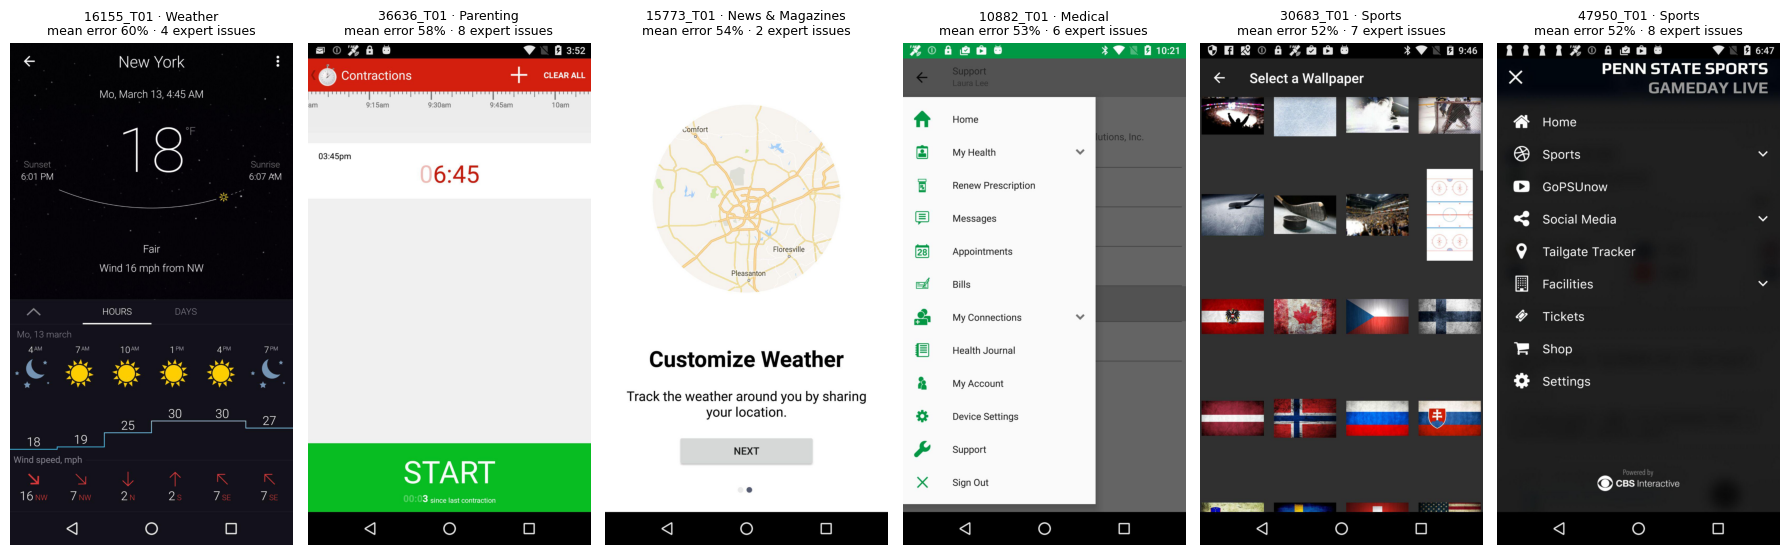

,Aesthetics expert,Aesthetics llm_mean,Learnability expert,Learnability llm_mean,Efficiency expert,Efficiency llm_mean,Usability expert,Usability llm_mean,Design Quality expert,Design Quality llm_mean
screen_task_id,,,,,,,,,,
16155_T01,4,8.2,2,5.0,2,4.8,4,9.8,4,8.2
36636_T01,3,6.0,2,5.0,2,5.0,4,9.8,3,7.0
15773_T01,3,7.5,2,4.8,2,4.5,4,9.0,4,7.0
10882_T01,4,6.8,2,4.8,2,4.8,4,9.2,4,7.5
30683_T01,3,6.0,2,5.0,2,4.8,4,8.8,3,5.8
47950_T01,3,6.5,2,4.5,2,4.5,4,8.8,3,6.8


In [20]:
def consensus_failures(prompting="zero_shot", top_n=6):
    d = norm_err[norm_err["prompting"] == prompting]
    worst = d.groupby("screen_task_id")["norm_abs_err"].mean().nlargest(top_n)
    detail = (d[d["screen_task_id"].isin(worst.index)]
              .groupby(["screen_task_id", "aspect"])
              .agg(expert=("expert_score", "first"), llm_mean=("llm_score", "mean"))
              .unstack("aspect").reindex(worst.index))
    detail.columns = [f"{ASPECT_LABELS[a]} {src}" for src, a in detail.columns]
    return worst, detail[[f"{ASPECT_LABELS[a]} {src}" for a in ASPECTS for src in ("expert", "llm_mean")]]

def show_screens(screen_task_ids, titles):
    screens = pd.read_parquet(SCREENS_FILE, columns=["screen_id", "base64_screen"]).set_index("screen_id")["base64_screen"]
    fig, axes = plt.subplots(1, len(screen_task_ids), figsize=(3 * len(screen_task_ids), 6.5))
    for ax, sid, title in zip(np.atleast_1d(axes), screen_task_ids, titles):
        raw = screens[int(sid.split("_")[0])]
        ax.imshow(Image.open(BytesIO(base64.b64decode(raw.split(",")[-1]))).convert("RGB"))
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    fig.tight_layout()
    plt.show()

worst_screens, worst_detail = consensus_failures()
meta = screen_meta.set_index("screen_task_id")
show_screens(worst_screens.index, [f"{sid} · {meta.at[sid, 'app_category']}\nmean error {err:.0f}% · "
                                   f"{meta.at[sid, 'n_issues']} expert issues" for sid, err in worst_screens.items()])
worst_detail.round(1)

# 7. Summary
Mean κ over aspects, median bias over aspects, and share of ratings within ±1 point of the expert.

In [21]:
summary_table = (
    bp_df.groupby(["model", "prompting"])["bp_kappa"].mean().rename("mean_bp_kappa").to_frame()
    .join(wilcoxon_df.groupby(["model", "prompting"])["median_delta"].median())
    .join(ratings_long.dropna(subset=["delta"]).assign(within_1=lambda d: d["delta"].abs() <= 1)
          .groupby(["model", "prompting"])["within_1"].mean().mul(100).rename("pct_within_1"))
    .reset_index()
    .sort_values(["prompting", "model"])
    .reset_index(drop=True)
)
summary_table.round({"mean_bp_kappa": 3, "median_delta": 2, "pct_within_1": 1})

,model,prompting,mean_bp_kappa,median_delta,pct_within_1
0,Claude-4,few_shot,0.599,1.0,53.2
1,GPT-5,few_shot,0.602,1.0,51.6
2,Gemini-2.5,few_shot,0.339,2.0,29.8
3,Qwen-3,few_shot,0.502,1.0,46.6
4,Claude-4,zero_shot,0.605,1.0,56.6
5,GPT-5,zero_shot,0.695,1.0,63.5
6,Gemini-2.5,zero_shot,0.408,1.0,34.5
7,Qwen-3,zero_shot,0.632,1.0,62.5


# 8. Supplementary Analyses

## 8.1 Inter-Model Agreement (BP κ between models, quadratic weights)

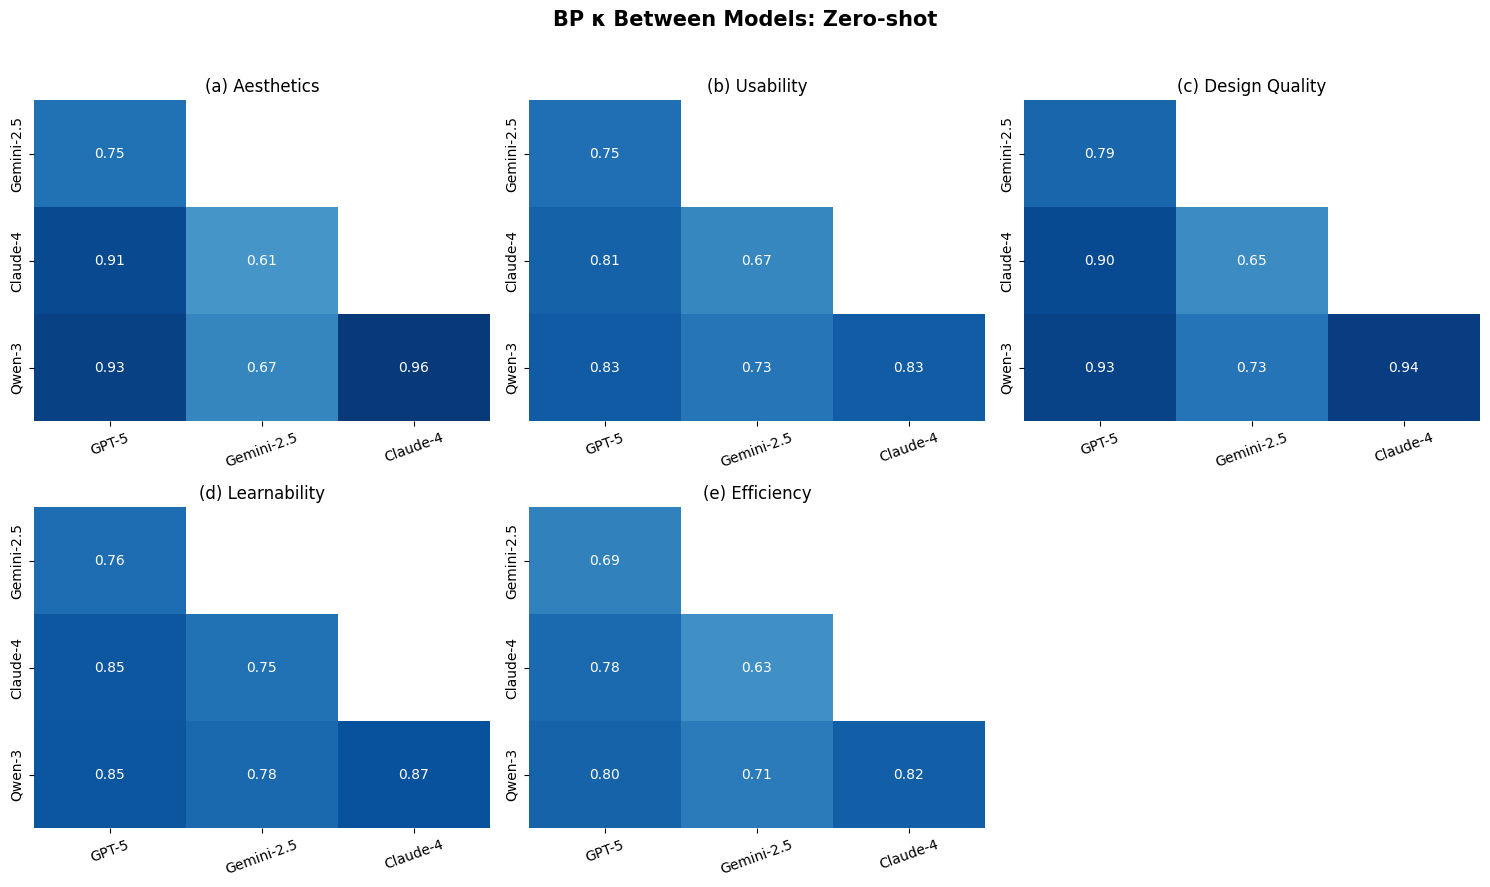

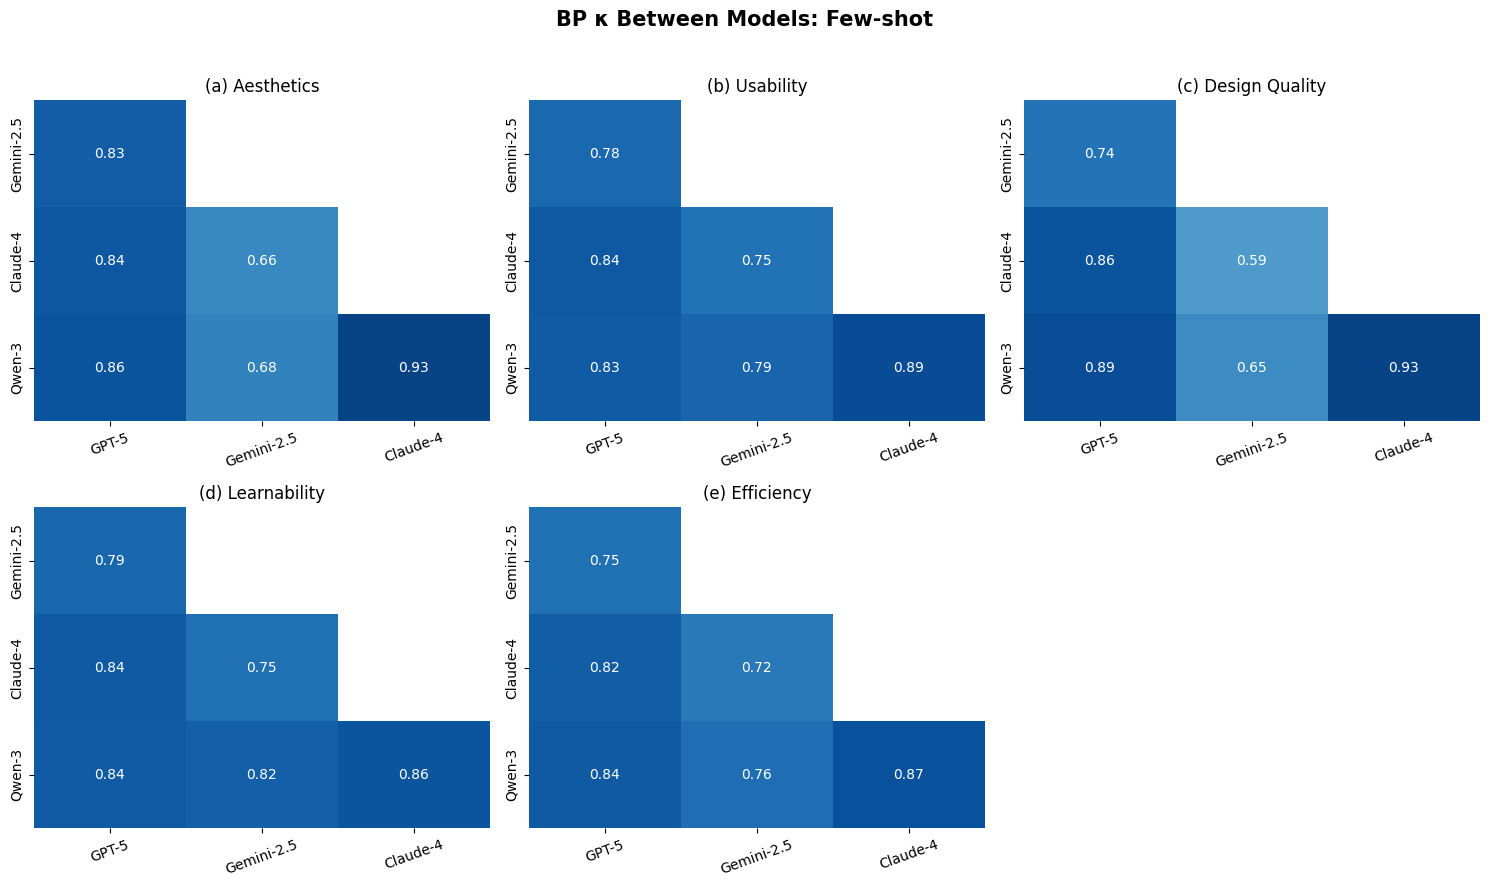

In [22]:
def inter_model_kappa(prompting, aspect):
    llm = pd.DataFrame({m: df.set_index("screen_task_id")[f"{aspect}_llm"] for m, df in model_dfs[prompting].items()})
    kappa = pd.DataFrame(np.nan, index=llm.columns, columns=llm.columns)
    for m1, m2 in combinations(llm.columns, 2):
        pair = llm[[m1, m2]].dropna().astype(int)
        kappa.loc[m2, m1] = bp_kappa(pair[m1], pair[m2], labels=CATEGORIES[aspect], weights_type="quadratic")
    return kappa.iloc[1:, :-1]   # lower triangle without the empty first row / last column

def plot_inter_model_kappa(prompting):
    fig, axes = aspect_grid(f"BP κ Between Models: {PROMPT_LABELS[prompting]}", figsize=(15, 9))
    for aspect, ax in axes.items():
        sns.heatmap(inter_model_kappa(prompting, aspect), annot=True, fmt=".2f", cmap="Blues",
                    vmin=0, vmax=1, cbar=False, ax=ax)
        ax.set_title(panel_title(aspect))
        ax.tick_params(axis="x", rotation=20)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

for prompting in PROMPTINGS:
    plot_inter_model_kappa(prompting)

# 9. Save Tables

In [23]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)
tables = {"rating_summary": rating_summary, "wilcoxon_vs_expert": wilcoxon_df, "bp_kappa_vs_expert": bp_df,
          "mae_by_expert_bin": mae_bin_df, "bin_shift": bin_shift_df.reset_index(),
          "error_by_category": category_err.stack(["prompting", "model"]).rename("norm_abs_err").reset_index(),
          "summary": summary_table}
for name, table in tables.items():
    table.to_csv(TABLES_DIR / f"{name}-{TASK_SUBSET}.csv", index=False)
print("Saved:", ", ".join(tables), "->", TABLES_DIR)

Saved: rating_summary, wilcoxon_vs_expert, bp_kappa_vs_expert, mae_by_expert_bin, bin_shift, error_by_category, summary -> ../results/ratings/analysis/tables
